# Trabalho Prático - Inteligência Artificial para Automação

## Detecção de Falhas e Análise de Eficiência em Motores Elétricos de Carros Elétricos

### Universidade Federal de [Universidade]
### Disciplina: Inteligência Artificial para Automação
### Data: Outubro 2025

---

**Equipe:**
- [Seu Nome]
- [Nome do Parceiro (se houver)]

**Objetivo:** Aplicar técnicas de Machine Learning para detectar falhas e analisar a eficiência de motores elétricos utilizados em veículos elétricos, no contexto da Indústria 4.0.

---

## 1. Contextualização e Formulação do Problema

### 1.1 Contexto da Indústria 4.0

Os motores elétricos são componentes críticos em veículos elétricos, representando cerca de 85-95% da eficiência energética total do sistema de propulsão. No contexto da **Indústria 4.0**, a manutenção preditiva e o monitoramento contínuo da performance desses motores são essenciais para:

- **Maximizar a autonomia** dos veículos elétricos
- **Reduzir custos de manutenção** através da detecção precoce de falhas
- **Aumentar a confiabilidade** e segurança dos veículos
- **Otimizar o consumo energético** para sustentabilidade

### 1.2 Definição do Problema

Este projeto aborda **dois problemas principais** de Machine Learning:

1. **Classificação (Detecção de Falhas):** 
   - Identificar quando um motor elétrico apresenta sinais de falha ou degradação
   - Classes: "Normal", "Falha Incipiente", "Falha Crítica"

2. **Regressão (Predição de Eficiência):**
   - Prever a eficiência energética do motor baseada em condições operacionais
   - Target: Percentual de eficiência (0-100%)

### 1.3 Variáveis Consideradas

**Sensores e Parâmetros Monitorados:**
- Temperatura do motor (°C)
- Corrente elétrica (A)
- Tensão de entrada (V)
- Velocidade de rotação (RPM)
- Torque aplicado (Nm)
- Vibração (m/s²)
- Tempo de operação (horas)
- Condições ambientais (temperatura externa, umidade)

### 1.4 Aplicações Práticas

- **Manutenção Preditiva:** Agendar manutenções antes de falhas críticas
- **Otimização Energética:** Ajustar parâmetros para máxima eficiência
- **Monitoramento em Tempo Real:** Alertas automáticos para operadores
- **Análise de Ciclo de Vida:** Prever durabilidade e performance ao longo do tempo

## 2. Importação de Bibliotecas e Configuração do Ambiente

Nesta seção, importamos todas as bibliotecas necessárias para o desenvolvimento do projeto de Machine Learning.

In [2]:
# Importações básicas para manipulação de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualizações
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Bibliotecas para Machine Learning
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           confusion_matrix, classification_report, roc_auc_score, roc_curve,
                           mean_squared_error, mean_absolute_error, r2_score)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, f_regression

# Bibliotecas adicionais
import datetime
import time
from scipy import stats
from scipy.stats import pearsonr
import joblib

# Verificação da versão das bibliotecas
print("Versões das principais bibliotecas:")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print("\n✅ Ambiente configurado com sucesso!")

Versões das principais bibliotecas:
Pandas: 2.3.3
NumPy: 1.24.3
Matplotlib: 3.7.2
Seaborn: 0.13.2
Scikit-learn: 1.7.2

✅ Ambiente configurado com sucesso!


## 3. Carregamento e Exploração Inicial dos Dados

Para este projeto, utilizaremos um dataset sintético que simula dados reais de sensores de motores elétricos. Este dataset contém informações sobre condições operacionais e indicadores de falhas.

In [3]:
# Função para gerar dataset sintético de motores elétricos
def gerar_dados_motor_eletrico(n_samples=5000, random_state=42):
    """
    Gera um dataset sintético simulando dados de sensores de motores elétricos
    de veículos elétricos com diferentes condições operacionais e falhas.
    """
    np.random.seed(random_state)
    
    # Gerando dados base
    data = {
        # Parâmetros elétricos
        'tensao_entrada': np.random.normal(400, 20, n_samples),  # Volts
        'corrente': np.random.normal(150, 30, n_samples),        # Amperes
        'potencia_entrada': np.random.normal(60, 15, n_samples), # kW
        
        # Parâmetros mecânicos
        'velocidade_rpm': np.random.normal(3000, 500, n_samples),  # RPM
        'torque': np.random.normal(200, 40, n_samples),            # Nm
        'vibracao': np.random.exponential(2, n_samples),           # m/s²
        
        # Parâmetros térmicos
        'temperatura_motor': np.random.normal(75, 15, n_samples),      # °C
        'temperatura_ambiente': np.random.normal(25, 10, n_samples),   # °C
        
        # Parâmetros operacionais
        'tempo_operacao': np.random.exponential(1000, n_samples),      # horas
        'umidade': np.random.normal(50, 15, n_samples),                # %
        'carga_aplicada': np.random.uniform(0.2, 1.0, n_samples),     # % carga nominal
    }
    
    df = pd.DataFrame(data)
    
    # Criando correlações realistas
    df['potencia_saida'] = (df['tensao_entrada'] * df['corrente'] * 0.85 * df['carga_aplicada']) / 1000
    
    # Calculando eficiência base
    eficiencia_base = (df['potencia_saida'] / df['potencia_entrada']) * 100
    eficiencia_base = np.clip(eficiencia_base, 70, 95)
    
    # Adicionando degradação por tempo de uso
    degradacao_tempo = np.clip(df['tempo_operacao'] / 10000, 0, 0.15)
    
    # Adicionando efeitos de temperatura
    efeito_temp = np.where(df['temperatura_motor'] > 90, 
                          (df['temperatura_motor'] - 90) * 0.1, 0)
    
    # Eficiência final
    df['eficiencia'] = eficiencia_base - (degradacao_tempo * 10) - efeito_temp
    df['eficiencia'] = np.clip(df['eficiencia'], 60, 95)
    
    # Criando indicadores de falha baseados em múltiplos fatores
    # Condições para diferentes tipos de falha
    condicao_normal = (
        (df['temperatura_motor'] < 85) & 
        (df['vibracao'] < 3) & 
        (df['tempo_operacao'] < 8000) &
        (df['eficiencia'] > 80)
    )
    
    condicao_falha_incipiente = (
        ((df['temperatura_motor'] >= 85) & (df['temperatura_motor'] < 100)) |
        ((df['vibracao'] >= 3) & (df['vibracao'] < 5)) |
        ((df['tempo_operacao'] >= 8000) & (df['tempo_operacao'] < 15000)) |
        ((df['eficiencia'] >= 70) & (df['eficiencia'] <= 80))
    )
    
    condicao_falha_critica = (
        (df['temperatura_motor'] >= 100) |
        (df['vibracao'] >= 5) |
        (df['tempo_operacao'] >= 15000) |
        (df['eficiencia'] < 70)
    )
    
    # Atribuindo status de falha
    df['status_falha'] = 'Normal'
    df.loc[condicao_falha_incipiente & ~condicao_falha_critica, 'status_falha'] = 'Falha_Incipiente'
    df.loc[condicao_falha_critica, 'status_falha'] = 'Falha_Critica'
    
    # Adicionando algumas variáveis derivadas úteis
    df['diferenca_temp'] = df['temperatura_motor'] - df['temperatura_ambiente']
    df['potencia_especifica'] = df['potencia_saida'] / df['velocidade_rpm'] * 1000
    df['fator_carga'] = df['torque'] / (df['potencia_saida'] * 1000 / (2 * np.pi * df['velocidade_rpm'] / 60))
    
    # Adicionando timestamp simulado
    start_date = pd.Timestamp('2024-01-01')
    df['timestamp'] = [start_date + pd.Timedelta(hours=i*0.1) for i in range(len(df))]
    
    return df

# Gerando o dataset
print("🔄 Gerando dataset sintético de motores elétricos...")
df_motor = gerar_dados_motor_eletrico(n_samples=5000, random_state=42)

print("✅ Dataset gerado com sucesso!")
print(f"📊 Dimensões do dataset: {df_motor.shape}")
print(f"📅 Período dos dados: {df_motor['timestamp'].min()} até {df_motor['timestamp'].max()}")

🔄 Gerando dataset sintético de motores elétricos...
✅ Dataset gerado com sucesso!
📊 Dimensões do dataset: (5000, 18)
📅 Período dos dados: 2024-01-01 00:00:00 até 2024-01-21 19:54:00


In [4]:
# Exploração inicial dos dados
print("📋 INFORMAÇÕES GERAIS DO DATASET")
print("=" * 50)
print(f"Número total de registros: {len(df_motor):,}")
print(f"Número de variáveis: {len(df_motor.columns)}")
print(f"Período dos dados: {(df_motor['timestamp'].max() - df_motor['timestamp'].min()).days} dias")

print("\n🔍 PRIMEIRAS 5 LINHAS:")
display(df_motor.head())

print("\n📊 INFORMAÇÕES SOBRE AS COLUNAS:")
df_motor.info()

print("\n📈 ESTATÍSTICAS DESCRITIVAS:")
display(df_motor.describe())

print("\n🏷️ DISTRIBUIÇÃO DAS CLASSES DE FALHA:")
distribuicao_falhas = df_motor['status_falha'].value_counts()
print(distribuicao_falhas)
print(f"\nPercentuais:")
for classe, count in distribuicao_falhas.items():
    percentual = (count / len(df_motor)) * 100
    print(f"{classe}: {percentual:.1f}%")

print("\n❌ VALORES AUSENTES:")
valores_ausentes = df_motor.isnull().sum()
if valores_ausentes.sum() > 0:
    print(valores_ausentes[valores_ausentes > 0])
else:
    print("✅ Não há valores ausentes no dataset!")

📋 INFORMAÇÕES GERAIS DO DATASET
Número total de registros: 5,000
Número de variáveis: 18
Período dos dados: 20 dias

🔍 PRIMEIRAS 5 LINHAS:


,tensao_entrada,corrente,potencia_entrada,velocidade_rpm,torque,vibracao,temperatura_motor,temperatura_ambiente,tempo_operacao,umidade,carga_aplicada,potencia_saida,eficiencia,status_falha,diferenca_temp,potencia_especifica,fator_carga,timestamp
0,409.934283,137.287210,49.822579,2928.288392,213.931450,1.533621,79.347599,20.334771,222.983617,36.673957,0.306834,14.677976,69.777016,Falha_Critica,59.012829,5.012476,4.469418,2024-01-01 00:00:00
1,397.234714,136.397577,55.417508,2983.672048,211.332944,10.626138,57.120045,20.550697,86.285601,20.806202,0.907136,41.777752,75.300995,Falha_Critica,36.569348,14.002126,1.580527,2024-01-01 00:06:00
2,412.953771,96.130705,51.039284,3032.147439,162.539206,0.306608,62.715021,35.047908,22.425847,41.985754,0.767879,25.910471,69.977574,Falha_Critica,27.667113,8.545254,1.991873,2024-01-01 00:12:00
3,430.460597,140.097294,61.656271,3473.430731,223.183369,3.964287,88.850054,35.117527,1446.436164,39.982485,0.657129,33.684679,68.553564,Falha_Critica,53.732528,9.697812,2.409998,2024-01-01 00:18:00
4,395.316933,171.984872,77.957678,2626.391346,140.396693,1.375138,103.153489,26.534304,663.699829,16.536305,0.459798,26.571855,68.020951,Falha_Critica,76.619185,10.117249,1.453192,2024-01-01 00:24:00



📊 INFORMAÇÕES SOBRE AS COLUNAS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   tensao_entrada        5000 non-null   float64       
 1   corrente              5000 non-null   float64       
 2   potencia_entrada      5000 non-null   float64       
 3   velocidade_rpm        5000 non-null   float64       
 4   torque                5000 non-null   float64       
 5   vibracao              5000 non-null   float64       
 6   temperatura_motor     5000 non-null   float64       
 7   temperatura_ambiente  5000 non-null   float64       
 8   tempo_operacao        5000 non-null   float64       
 9   umidade               5000 non-null   float64       
 10  carga_aplicada        5000 non-null   float64       
 11  potencia_saida        5000 non-null   float64       
 12  eficiencia            5000 non-null   float

,tensao_entrada,corrente,potencia_entrada,velocidade_rpm,torque,vibracao,temperatura_motor,temperatura_ambiente,tempo_operacao,umidade,carga_aplicada,potencia_saida,eficiencia,diferenca_temp,potencia_especifica,fator_carga,timestamp
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000
mean,400.112039,149.703783,60.158295,3008.257552,199.265909,1.974453,74.992223,24.738962,1001.354664,49.932164,0.601304,30.628798,73.268370,50.253261,10.491774,2.607726,2024-01-11 09:57:00
min,335.174653,32.327992,9.366313,1071.812335,53.796539,0.000011,8.015942,-7.520294,0.387488,-14.430865,0.200216,2.987588,65.196790,-22.779313,0.855653,0.356524,2024-01-01 00:00:00
25%,386.841899,129.402513,50.086704,2667.659628,171.929596,0.563507,64.543053,17.959761,296.158768,40.070039,0.401005,19.403669,68.734671,37.344021,6.392444,1.468602,2024-01-06 04:58:30
50%,400.269312,149.476484,60.148762,3009.629569,199.679327,1.381834,74.902430,24.811152,711.033577,50.063195,0.601978,29.433885,69.504777,50.296215,9.778352,2.121625,2024-01-11 09:57:00
75%,413.320212,170.317142,70.133014,3353.307326,226.024258,2.690069,85.518668,31.462939,1384.722059,59.996402,0.803549,40.416449,69.998827,62.780195,13.734694,3.271846,2024-01-16 14:55:30
max,478.524754,255.871656,111.433657,5239.542126,344.454003,16.930832,130.917500,58.352682,8748.498068,100.709217,0.999478,79.734414,94.999372,116.271641,38.561030,20.814608,2024-01-21 19:54:00
std,19.929597,30.313113,14.981548,501.668343,39.334986,1.971720,15.322708,9.891048,985.669337,14.804575,0.231836,13.637889,8.441630,18.428765,5.112260,1.696607,NaN



🏷️ DISTRIBUIÇÃO DAS CLASSES DE FALHA:
status_falha
Falha_Critica       3911
Falha_Incipiente     613
Normal               476
Name: count, dtype: int64

Percentuais:
Falha_Critica: 78.2%
Falha_Incipiente: 12.3%
Normal: 9.5%

❌ VALORES AUSENTES:
✅ Não há valores ausentes no dataset!


## 4. Análise Exploratória dos Dados (EDA)

A análise exploratória é fundamental para compreender os padrões nos dados, identificar correlações e preparar estratégias de modelagem adequadas.

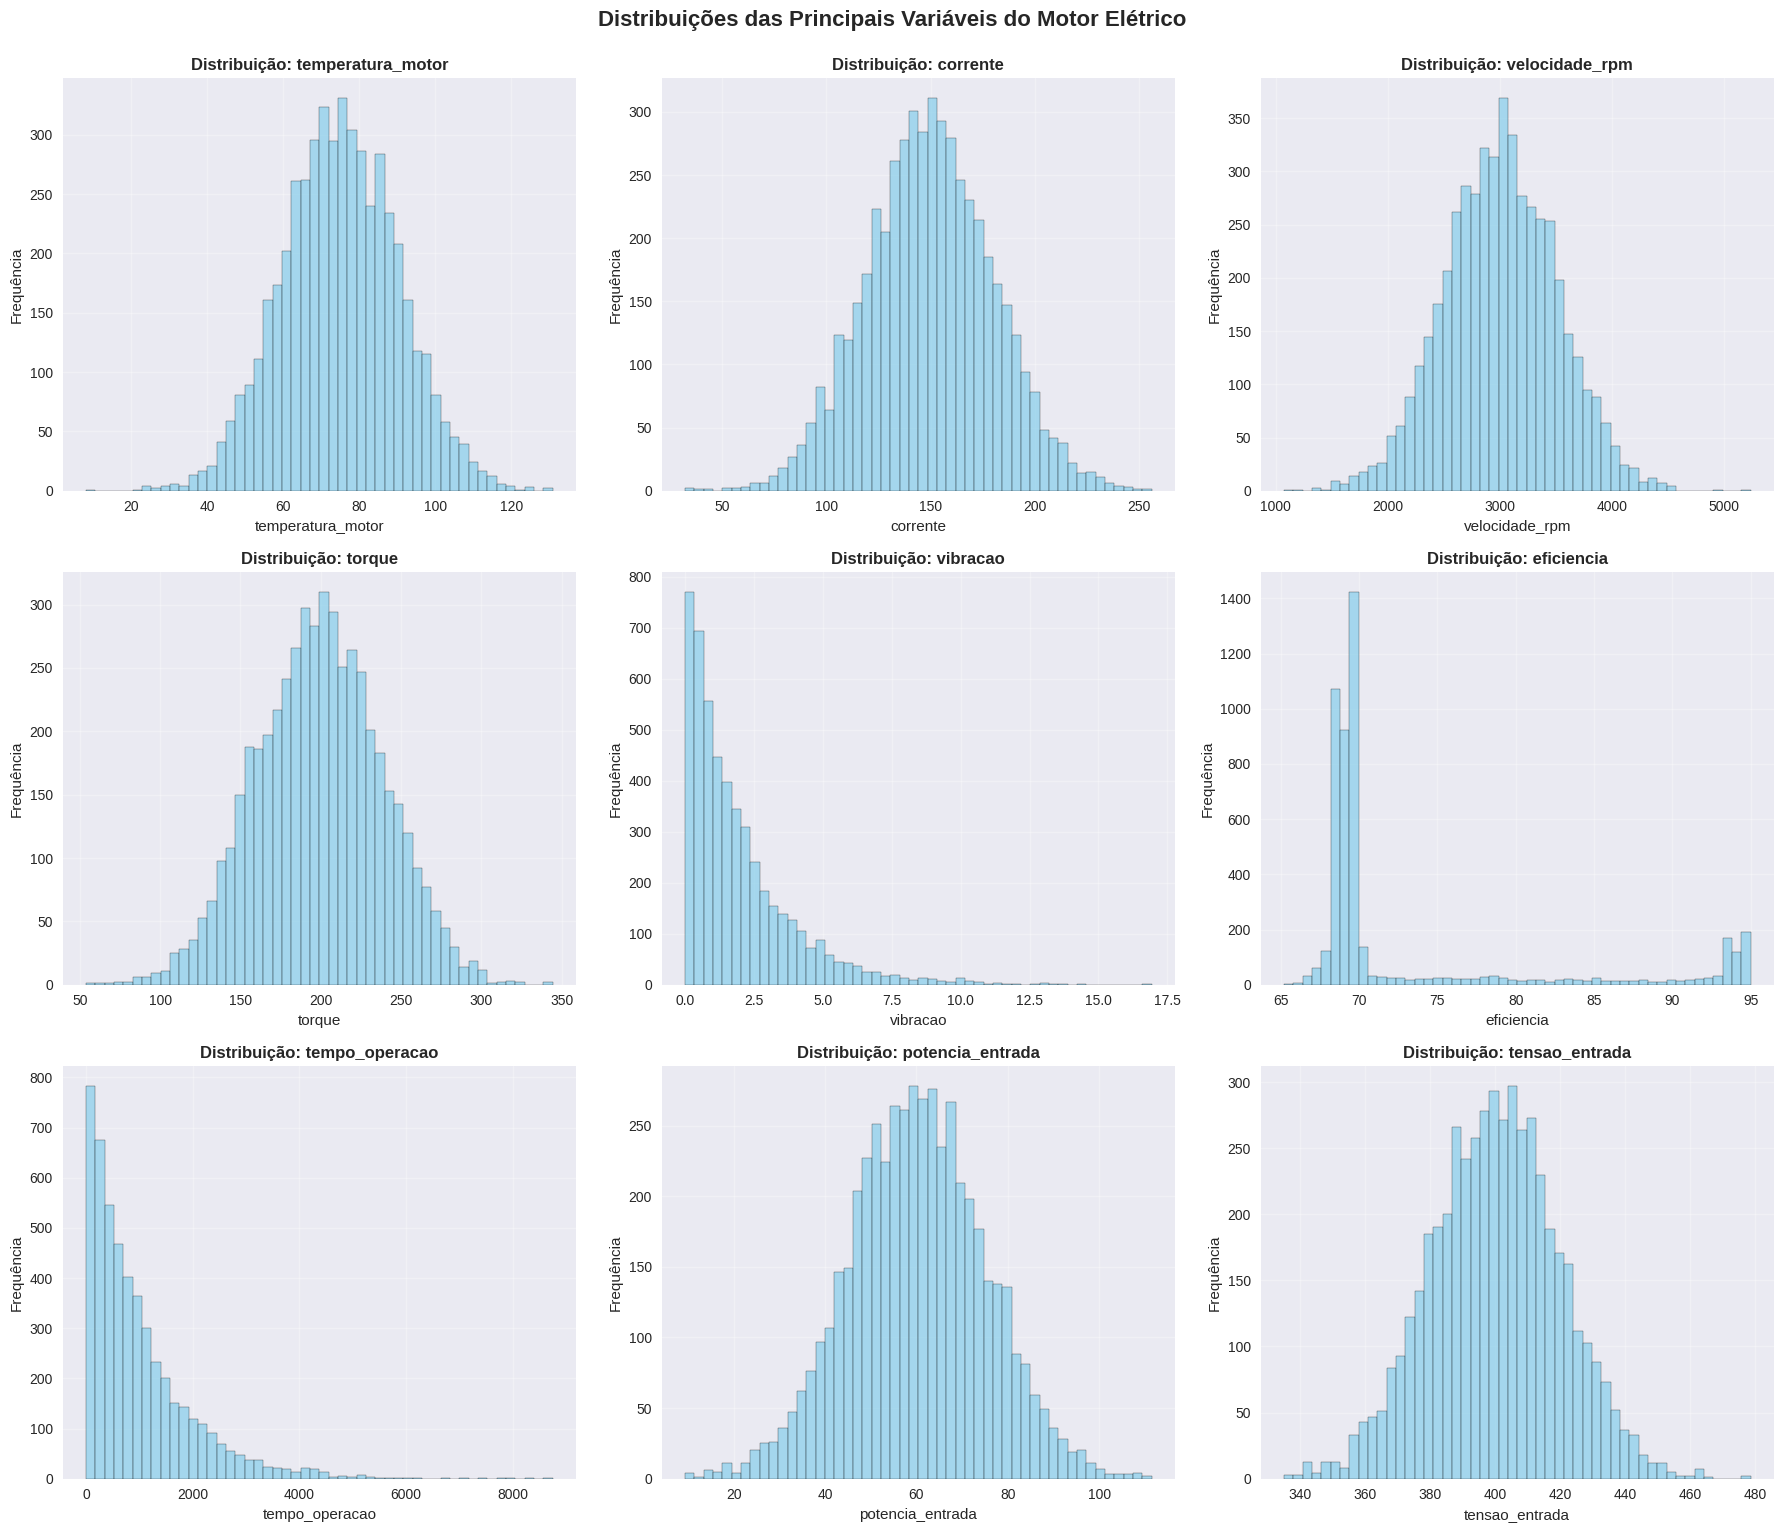

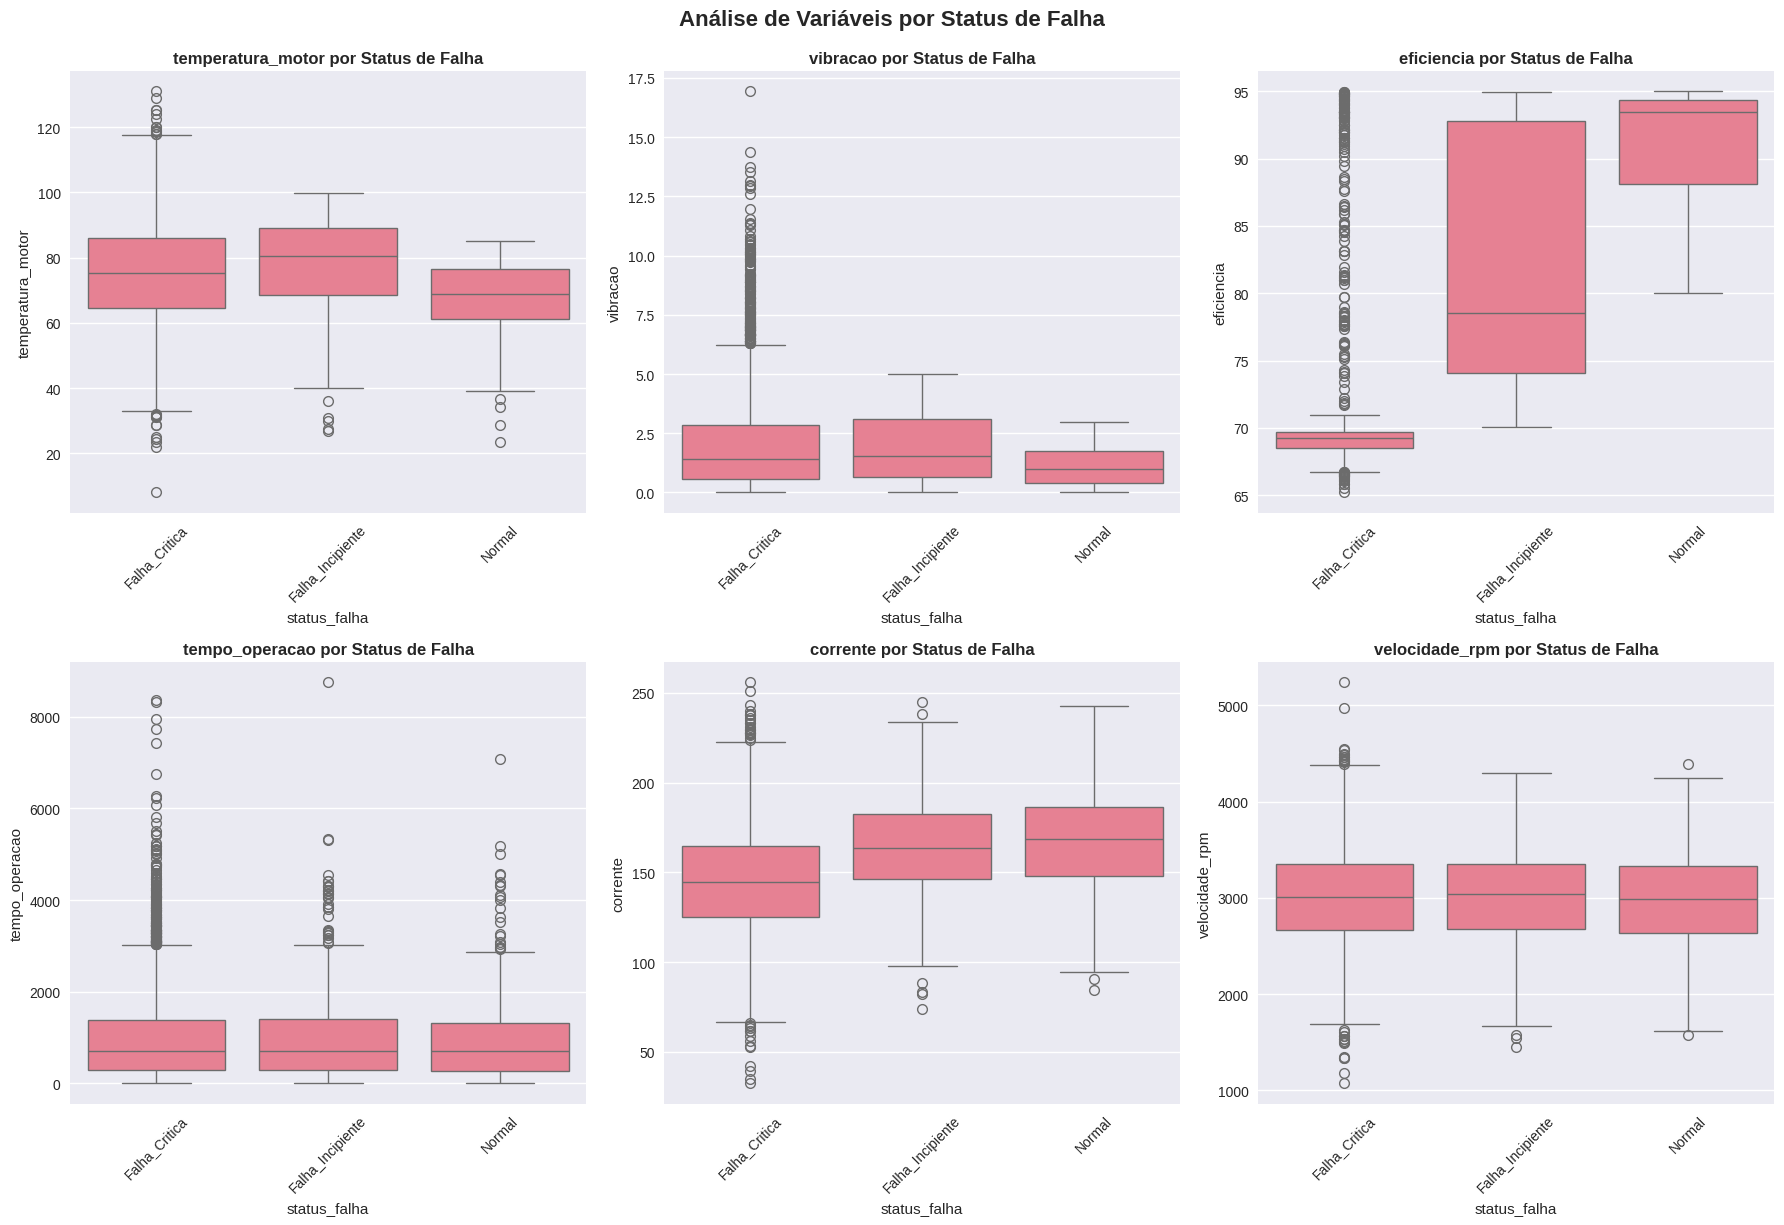

In [5]:
# 4.1 Distribuições das variáveis numéricas principais
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

variaveis_principais = [
    'temperatura_motor', 'corrente', 'velocidade_rpm', 'torque', 
    'vibracao', 'eficiencia', 'tempo_operacao', 'potencia_entrada', 'tensao_entrada'
]

for i, var in enumerate(variaveis_principais):
    axes[i].hist(df_motor[var], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribuição: {var}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequência')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Distribuições das Principais Variáveis do Motor Elétrico', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# 4.2 Boxplot das variáveis por status de falha
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

variaveis_analise = ['temperatura_motor', 'vibracao', 'eficiencia', 'tempo_operacao', 'corrente', 'velocidade_rpm']

for i, var in enumerate(variaveis_analise):
    sns.boxplot(data=df_motor, x='status_falha', y=var, ax=axes[i])
    axes[i].set_title(f'{var} por Status de Falha', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('Análise de Variáveis por Status de Falha', fontsize=16, fontweight='bold', y=1.02)
plt.show()

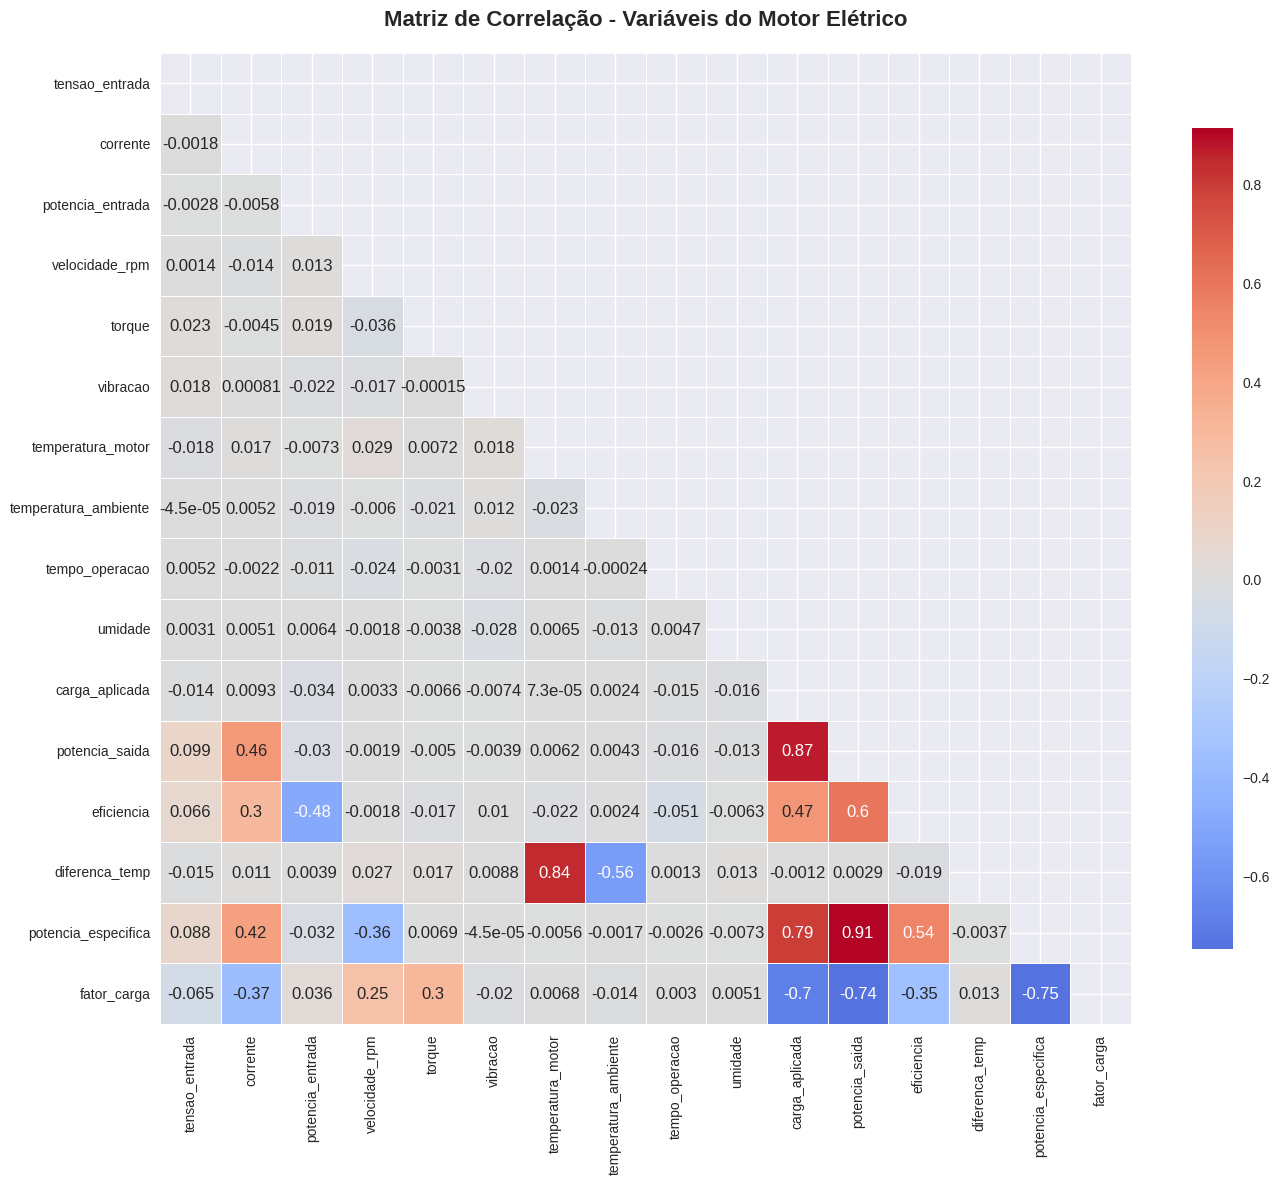

📊 CORRELAÇÕES MAIS FORTES COM EFICIÊNCIA:
potencia_saida: 0.596
potencia_especifica: 0.543
potencia_entrada: 0.484
carga_aplicada: 0.472
fator_carga: 0.353
corrente: 0.295
tensao_entrada: 0.066
tempo_operacao: 0.051
temperatura_motor: 0.022
diferenca_temp: 0.019
torque: 0.017
vibracao: 0.010
umidade: 0.006
temperatura_ambiente: 0.002
velocidade_rpm: 0.002

🔗 CORRELAÇÕES MAIS FORTES NO DATASET (|r| > 0.5):
temperatura_motor <-> diferenca_temp: 0.844
temperatura_ambiente <-> diferenca_temp: -0.556
carga_aplicada <-> potencia_saida: 0.867
carga_aplicada <-> potencia_especifica: 0.790
carga_aplicada <-> fator_carga: -0.696
potencia_saida <-> eficiencia: 0.596
potencia_saida <-> potencia_especifica: 0.912
potencia_saida <-> fator_carga: -0.742
eficiencia <-> potencia_especifica: 0.543
potencia_especifica <-> fator_carga: -0.749


In [6]:
# 4.3 Matriz de correlação
# Selecionando apenas variáveis numéricas para correlação
numeric_columns = df_motor.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns = [col for col in numeric_columns if col not in ['timestamp']]

# Calculando matriz de correlação
correlation_matrix = df_motor[numeric_columns].corr()

# Visualização da matriz de correlação
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlação - Variáveis do Motor Elétrico', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificando correlações mais fortes com eficiência
correlacoes_eficiencia = correlation_matrix['eficiencia'].abs().sort_values(ascending=False)
print("📊 CORRELAÇÕES MAIS FORTES COM EFICIÊNCIA:")
print("=" * 50)
for var, corr in correlacoes_eficiencia.items():
    if var != 'eficiencia':
        print(f"{var}: {corr:.3f}")

# Identificando correlações mais fortes em geral
print("\n🔗 CORRELAÇÕES MAIS FORTES NO DATASET (|r| > 0.5):")
print("=" * 60)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = abs(correlation_matrix.iloc[i, j])
        if corr_val > 0.5:
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            print(f"{var1} <-> {var2}: {correlation_matrix.iloc[i, j]:.3f}")

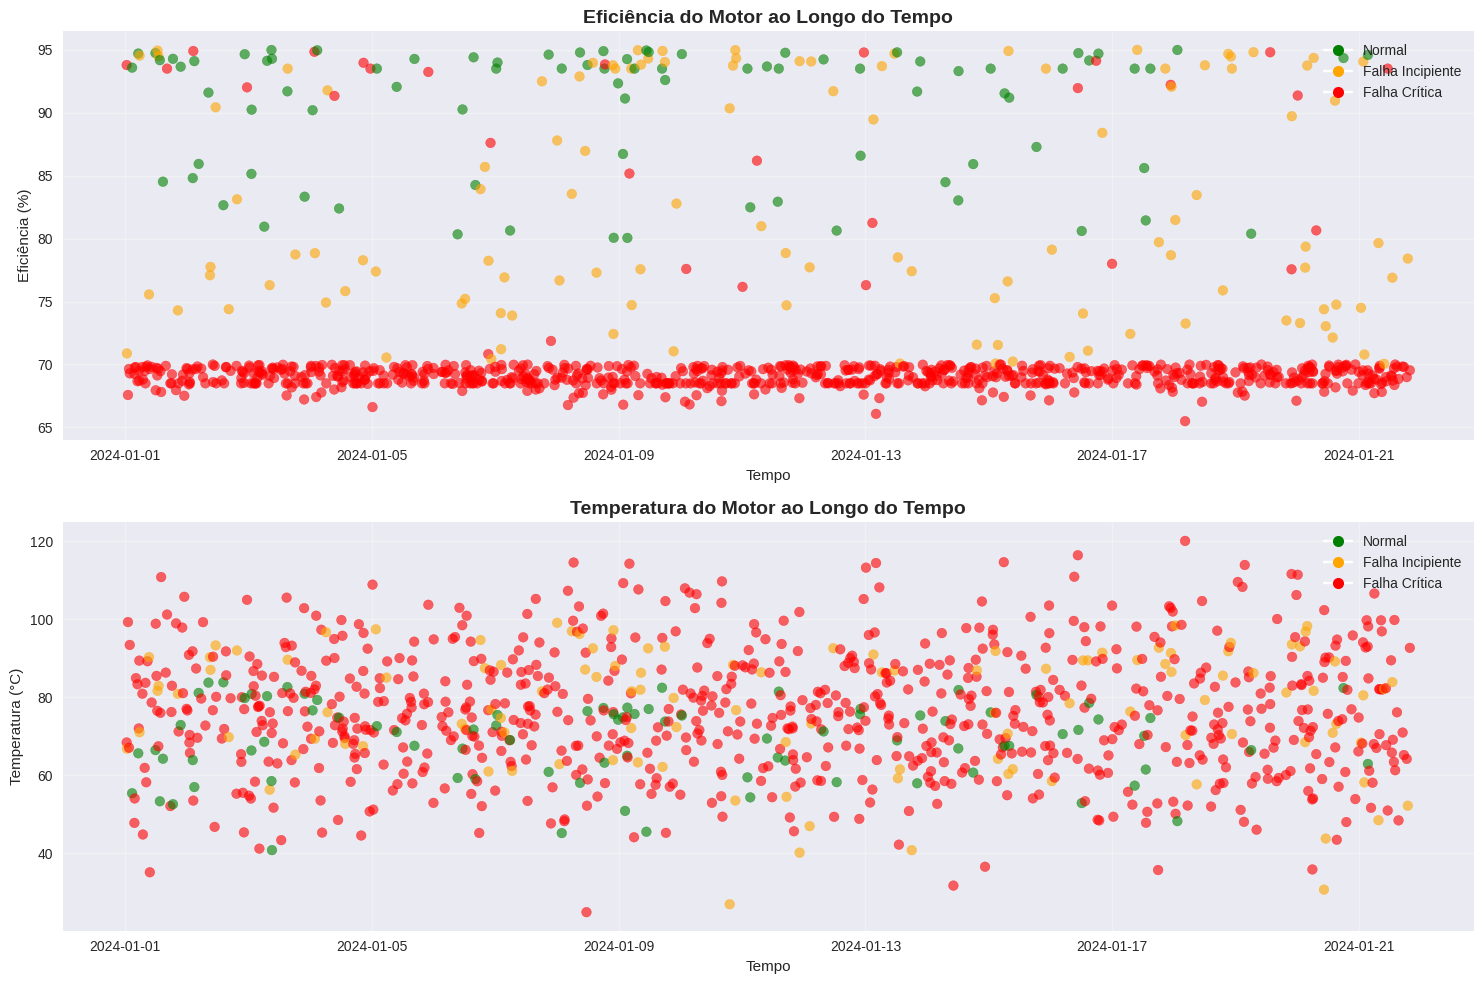

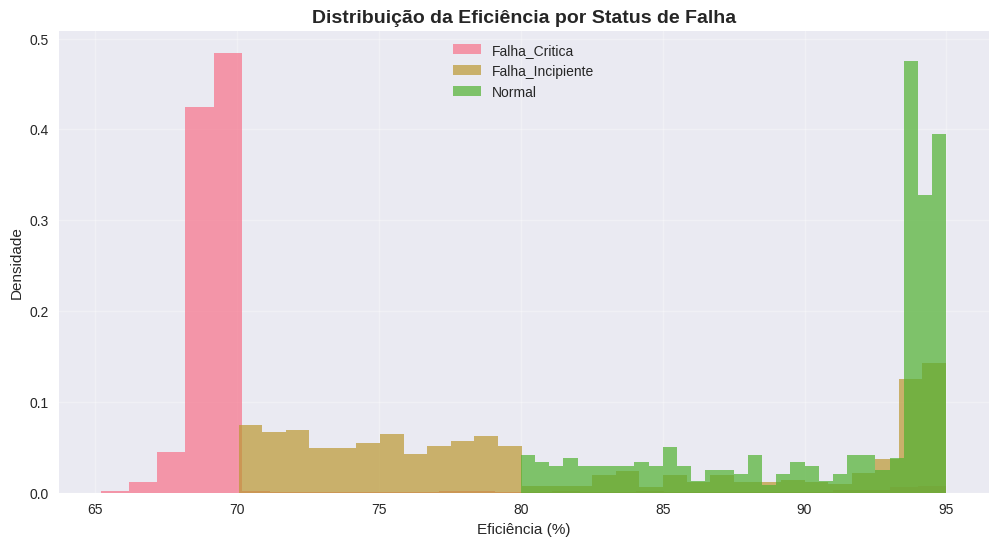

📊 ESTATÍSTICAS DE EFICIÊNCIA POR CLASSE:


,count,mean,std,min,25%,50%,75%,max
status_falha,,,,,,,,
Falha_Critica,3911.0,69.776990,3.793452,65.196790,68.500000,69.213712,69.699379,94.986154
Falha_Incipiente,613.0,81.695415,8.803090,70.048771,74.047151,78.516328,92.776152,94.987880
Normal,476.0,91.102418,4.575009,80.000174,88.088433,93.500000,94.379099,94.999372


In [7]:
# 4.4 Análise temporal da eficiência e temperatura
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Eficiência ao longo do tempo
df_motor_sample = df_motor.sample(1000).sort_values('timestamp')  # Amostra para visualização
ax1.scatter(df_motor_sample['timestamp'], df_motor_sample['eficiencia'], 
           c=df_motor_sample['status_falha'].map({'Normal': 'green', 'Falha_Incipiente': 'orange', 'Falha_Critica': 'red'}),
           alpha=0.6)
ax1.set_title('Eficiência do Motor ao Longo do Tempo', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tempo')
ax1.set_ylabel('Eficiência (%)')
ax1.grid(True, alpha=0.3)

# Temperatura ao longo do tempo
ax2.scatter(df_motor_sample['timestamp'], df_motor_sample['temperatura_motor'], 
           c=df_motor_sample['status_falha'].map({'Normal': 'green', 'Falha_Incipiente': 'orange', 'Falha_Critica': 'red'}),
           alpha=0.6)
ax2.set_title('Temperatura do Motor ao Longo do Tempo', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tempo')
ax2.set_ylabel('Temperatura (°C)')
ax2.grid(True, alpha=0.3)

# Legenda
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='green', label='Normal', markersize=8),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', label='Falha Incipiente', markersize=8),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Falha Crítica', markersize=8)]
ax1.legend(handles=legend_elements, loc='upper right')
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# 4.5 Análise da distribuição da eficiência por classe
plt.figure(figsize=(12, 6))
for status in df_motor['status_falha'].unique():
    subset = df_motor[df_motor['status_falha'] == status]
    plt.hist(subset['eficiencia'], bins=30, alpha=0.7, label=status, density=True)

plt.title('Distribuição da Eficiência por Status de Falha', fontsize=14, fontweight='bold')
plt.xlabel('Eficiência (%)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Estatísticas por classe
print("📊 ESTATÍSTICAS DE EFICIÊNCIA POR CLASSE:")
print("=" * 50)
estatisticas_eficiencia = df_motor.groupby('status_falha')['eficiencia'].describe()
display(estatisticas_eficiencia)

## 5. Pré-processamento dos Dados

Nesta etapa, preparamos os dados para os algoritmos de Machine Learning, incluindo tratamento de outliers, normalização e engenharia de features.

🔍 ANÁLISE DE OUTLIERS:
temperatura_motor:
  - Outliers detectados: 33 (0.7%)
  - Limites: [33.08, 116.98]
corrente:
  - Outliers detectados: 34 (0.7%)
  - Limites: [68.03, 231.69]
vibracao:
  - Outliers detectados: 249 (5.0%)
  - Limites: [-2.63, 5.88]
eficiencia:
  - Outliers detectados: 1189 (23.8%)
  - Limites: [66.84, 71.90]
velocidade_rpm:
  - Outliers detectados: 36 (0.7%)
  - Limites: [1639.19, 4381.78]


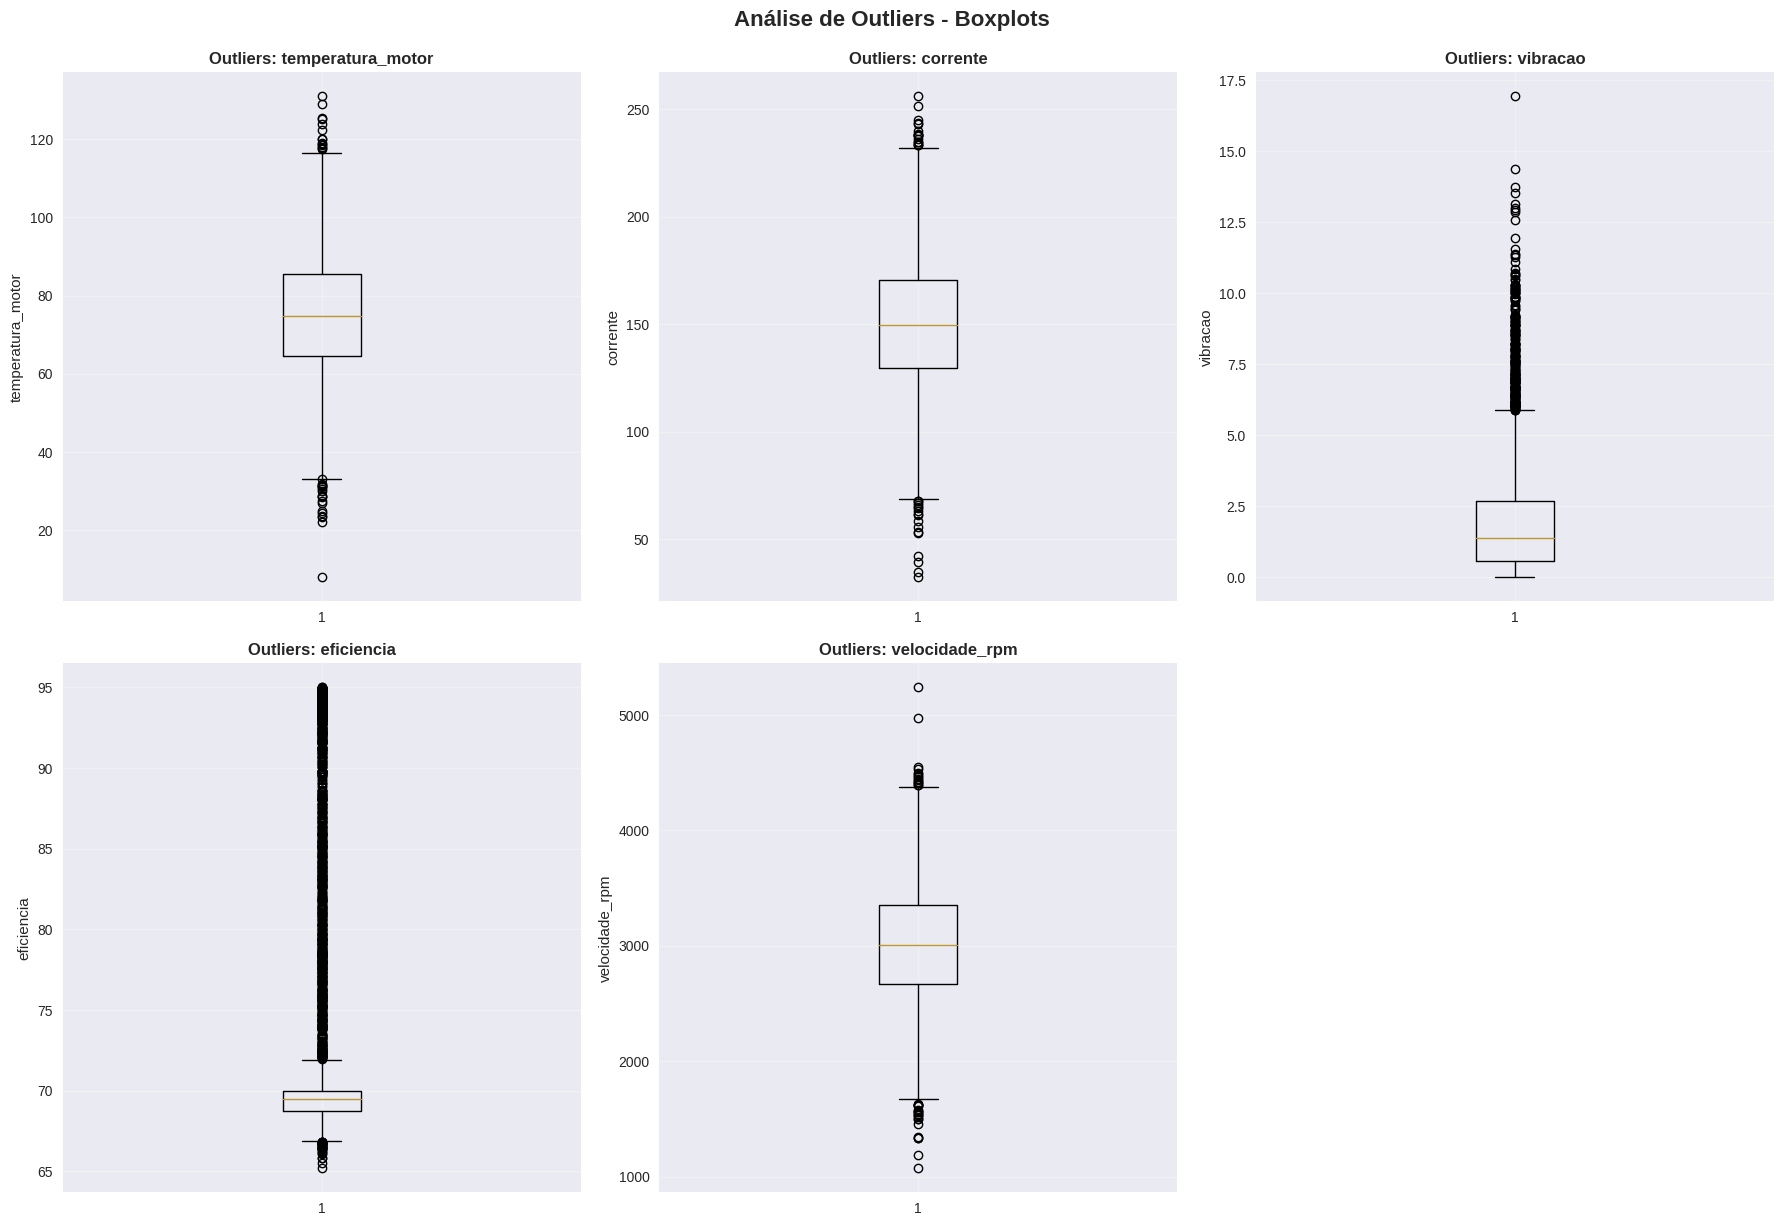


🔧 TRATAMENTO DE OUTLIERS:
Outliers extremos a serem removidos: 144 registros (2.88%)
Dataset após remoção: 4856 registros


In [8]:
# 5.1 Detecção e tratamento de outliers
def detectar_outliers_iqr(df, coluna):
    """Detecta outliers usando o método IQR"""
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
    return outliers.index, limite_inferior, limite_superior

# Criando uma cópia dos dados para pré-processamento
df_processed = df_motor.copy()

# Analisando outliers nas principais variáveis
variaveis_outliers = ['temperatura_motor', 'corrente', 'vibracao', 'eficiencia', 'velocidade_rpm']

print("🔍 ANÁLISE DE OUTLIERS:")
print("=" * 50)

outliers_info = {}
for var in variaveis_outliers:
    outlier_indices, lim_inf, lim_sup = detectar_outliers_iqr(df_processed, var)
    outliers_info[var] = {
        'indices': outlier_indices,
        'count': len(outlier_indices),
        'percentage': (len(outlier_indices) / len(df_processed)) * 100,
        'lim_inf': lim_inf,
        'lim_sup': lim_sup
    }
    
    print(f"{var}:")
    print(f"  - Outliers detectados: {len(outlier_indices)} ({(len(outlier_indices)/len(df_processed)*100):.1f}%)")
    print(f"  - Limites: [{lim_inf:.2f}, {lim_sup:.2f}]")

# Visualização dos outliers
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, var in enumerate(variaveis_outliers):
    if i < len(axes):
        axes[i].boxplot(df_processed[var])
        axes[i].set_title(f'Outliers: {var}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(var)
        axes[i].grid(True, alpha=0.3)

# Removendo o subplot extra
if len(variaveis_outliers) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.suptitle('Análise de Outliers - Boxplots', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Tratamento conservador de outliers extremos (mantendo a maioria dos dados)
print("\n🔧 TRATAMENTO DE OUTLIERS:")
print("=" * 30)

# Para este projeto, vamos usar uma abordagem conservadora e manter outliers que podem ser válidos
# Removendo apenas outliers muito extremos (> 3 desvios padrão)
outliers_extremos = []

for var in variaveis_outliers:
    mean_val = df_processed[var].mean()
    std_val = df_processed[var].std()
    limite_extremo_inf = mean_val - 3 * std_val
    limite_extremo_sup = mean_val + 3 * std_val
    
    outliers_var = df_processed[(df_processed[var] < limite_extremo_inf) | 
                               (df_processed[var] > limite_extremo_sup)].index
    outliers_extremos.extend(outliers_var)

outliers_extremos = list(set(outliers_extremos))
print(f"Outliers extremos a serem removidos: {len(outliers_extremos)} registros ({len(outliers_extremos)/len(df_processed)*100:.2f}%)")

# Removendo outliers extremos
df_processed = df_processed.drop(outliers_extremos)
print(f"Dataset após remoção: {df_processed.shape[0]} registros")

In [9]:
# 5.2 Engenharia de Features
print("🔧 ENGENHARIA DE FEATURES:")
print("=" * 40)

# Criando features derivadas que podem ser importantes para o diagnóstico
print("Criando features derivadas...")

# 1. Razões e índices de performance
df_processed['razao_potencia'] = df_processed['potencia_saida'] / df_processed['potencia_entrada']
df_processed['indice_temperatura'] = df_processed['temperatura_motor'] / df_processed['temperatura_ambiente']
df_processed['densidade_potencia'] = df_processed['potencia_saida'] / df_processed['velocidade_rpm'] * 1000

# 2. Features de degradação
df_processed['horas_normalizadas'] = df_processed['tempo_operacao'] / df_processed['tempo_operacao'].max()
df_processed['degradacao_termica'] = np.where(df_processed['temperatura_motor'] > 80, 
                                            (df_processed['temperatura_motor'] - 80) / 20, 0)

# 3. Features de stress operacional
df_processed['stress_eletrico'] = (df_processed['corrente'] * df_processed['tensao_entrada']) / 1000
df_processed['stress_mecanico'] = df_processed['torque'] * df_processed['velocidade_rpm'] / 1000
df_processed['stress_total'] = df_processed['stress_eletrico'] + df_processed['stress_mecanico']

# 4. Indicadores de condição
df_processed['condicao_operacional'] = (
    (df_processed['temperatura_motor'] < 85).astype(int) * 0.3 +
    (df_processed['vibracao'] < 3).astype(int) * 0.3 +
    (df_processed['eficiencia'] > 80).astype(int) * 0.4
)

# 5. Features temporais (baseadas no timestamp)
df_processed['hora'] = df_processed['timestamp'].dt.hour
df_processed['dia_semana'] = df_processed['timestamp'].dt.dayofweek
df_processed['mes'] = df_processed['timestamp'].dt.month

print(f"✅ Features criadas com sucesso!")
print(f"Dataset agora possui {df_processed.shape[1]} colunas")

# Listando as novas features
novas_features = [
    'razao_potencia', 'indice_temperatura', 'densidade_potencia',
    'horas_normalizadas', 'degradacao_termica', 'stress_eletrico', 
    'stress_mecanico', 'stress_total', 'condicao_operacional',
    'hora', 'dia_semana', 'mes'
]

print(f"\nNovas features criadas: {len(novas_features)}")
for feature in novas_features:
    print(f"  - {feature}")

# 5.3 Seleção e preparação das features para modelagem
print("\n📊 PREPARAÇÃO PARA MODELAGEM:")
print("=" * 40)

# Features que não serão usadas na modelagem
features_excluir = ['timestamp']  # Timestamp não deve ser usado diretamente

# Separando features numéricas e categóricas
features_numericas = df_processed.select_dtypes(include=[np.number]).columns.tolist()
features_numericas = [f for f in features_numericas if f not in features_excluir + ['eficiencia']]

features_categoricas = ['status_falha']

print(f"Features numéricas para modelagem: {len(features_numericas)}")
print(f"Features categóricas: {len(features_categoricas)}")

# Verificando a distribuição das classes após o pré-processamento
print("\n📊 DISTRIBUIÇÃO DAS CLASSES APÓS PRÉ-PROCESSAMENTO:")
distribuicao_final = df_processed['status_falha'].value_counts()
print(distribuicao_final)
print(f"\nPercentuais:")
for classe, count in distribuicao_final.items():
    percentual = (count / len(df_processed)) * 100
    print(f"{classe}: {percentual:.1f}%")

🔧 ENGENHARIA DE FEATURES:
Criando features derivadas...
✅ Features criadas com sucesso!
Dataset agora possui 30 colunas

Novas features criadas: 12
  - razao_potencia
  - indice_temperatura
  - densidade_potencia
  - horas_normalizadas
  - degradacao_termica
  - stress_eletrico
  - stress_mecanico
  - stress_total
  - condicao_operacional
  - hora
  - dia_semana
  - mes

📊 PREPARAÇÃO PARA MODELAGEM:
Features numéricas para modelagem: 27
Features categóricas: 1

📊 DISTRIBUIÇÃO DAS CLASSES APÓS PRÉ-PROCESSAMENTO:
status_falha
Falha_Critica       3774
Falha_Incipiente     609
Normal               473
Name: count, dtype: int64

Percentuais:
Falha_Critica: 77.7%
Falha_Incipiente: 12.5%
Normal: 9.7%


## 6. Divisão dos Dados e Preparação para Modelagem

Dividimos os dados em conjuntos de treino, validação e teste, e aplicamos normalização adequada.

In [10]:
# 6.1 Preparação dos dados para ambos os problemas
print("🎯 PREPARAÇÃO DOS DATASETS:")
print("=" * 40)

# Definindo X (features) e y (targets)
X = df_processed[features_numericas].copy()

# Para classificação (detecção de falhas)
y_classificacao = df_processed['status_falha'].copy()

# Para regressão (predição de eficiência)
y_regressao = df_processed['eficiencia'].copy()

print(f"Número de features: {X.shape[1]}")
print(f"Número de amostras: {X.shape[0]}")
print(f"Problema de classificação - Classes: {y_classificacao.unique()}")
print(f"Problema de regressão - Range eficiência: {y_regressao.min():.1f}% - {y_regressao.max():.1f}%")

# 6.2 Codificação da variável target para classificação
label_encoder = LabelEncoder()
y_classificacao_encoded = label_encoder.fit_transform(y_classificacao)

# Mapeamento das classes
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\nMapeamento das classes: {class_mapping}")

# 6.3 Divisão dos dados
print("\n📊 DIVISÃO DOS DADOS:")
print("=" * 30)

# Para classificação
X_train_clf, X_temp_clf, y_train_clf, y_temp_clf = train_test_split(
    X, y_classificacao_encoded, test_size=0.4, random_state=42, stratify=y_classificacao_encoded
)

X_val_clf, X_test_clf, y_val_clf, y_test_clf = train_test_split(
    X_temp_clf, y_temp_clf, test_size=0.5, random_state=42, stratify=y_temp_clf
)

# Para regressão
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X, y_regressao, test_size=0.4, random_state=42
)

X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.5, random_state=42
)

print("Distribuição dos dados:")
print(f"Treino: {len(X_train_clf)} amostras ({len(X_train_clf)/len(X)*100:.1f}%)")
print(f"Validação: {len(X_val_clf)} amostras ({len(X_val_clf)/len(X)*100:.1f}%)")
print(f"Teste: {len(X_test_clf)} amostras ({len(X_test_clf)/len(X)*100:.1f}%)")

# 6.4 Normalização/Padronização das features
print("\n🔧 NORMALIZAÇÃO DOS DADOS:")
print("=" * 30)

# Usando StandardScaler para normalizar os dados
scaler = StandardScaler()

# Fit apenas no conjunto de treino
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_val_clf_scaled = scaler.transform(X_val_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

# Para regressão (mesmo scaler)
X_train_reg_scaled = scaler.transform(X_train_reg)
X_val_reg_scaled = scaler.transform(X_val_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

print("✅ Dados normalizados com StandardScaler")
print(f"Média das features (treino): {X_train_clf_scaled.mean():.6f}")
print(f"Desvio padrão das features (treino): {X_train_clf_scaled.std():.6f}")

# 6.5 Verificação da distribuição das classes nos conjuntos
print("\n📊 DISTRIBUIÇÃO DAS CLASSES NOS CONJUNTOS:")
print("=" * 50)

conjuntos = [
    ("Treino", y_train_clf),
    ("Validação", y_val_clf),
    ("Teste", y_test_clf)
]

for nome, y_data in conjuntos:
    print(f"\n{nome}:")
    unique, counts = np.unique(y_data, return_counts=True)
    for i, (classe, count) in enumerate(zip(unique, counts)):
        classe_nome = label_encoder.inverse_transform([classe])[0]
        percentual = (count / len(y_data)) * 100
        print(f"  {classe_nome}: {count} ({percentual:.1f}%)")

print(f"\n✅ Dados preparados para modelagem!")
print(f"🎯 Features selecionadas: {len(features_numericas)}")
print(f"📊 Total de amostras: {len(X)}")

🎯 PREPARAÇÃO DOS DATASETS:
Número de features: 27
Número de amostras: 4856
Problema de classificação - Classes: ['Falha_Critica' 'Falha_Incipiente' 'Normal']
Problema de regressão - Range eficiência: 65.5% - 95.0%

Mapeamento das classes: {'Falha_Critica': 0, 'Falha_Incipiente': 1, 'Normal': 2}

📊 DIVISÃO DOS DADOS:
Distribuição dos dados:
Treino: 2913 amostras (60.0%)
Validação: 971 amostras (20.0%)
Teste: 972 amostras (20.0%)

🔧 NORMALIZAÇÃO DOS DADOS:
✅ Dados normalizados com StandardScaler
Média das features (treino): 0.000000
Desvio padrão das features (treino): 0.981307

📊 DISTRIBUIÇÃO DAS CLASSES NOS CONJUNTOS:

Treino:
  Falha_Critica: 2264 (77.7%)
  Falha_Incipiente: 365 (12.5%)
  Normal: 284 (9.7%)

Validação:
  Falha_Critica: 755 (77.8%)
  Falha_Incipiente: 122 (12.6%)
  Normal: 94 (9.7%)

Teste:
  Falha_Critica: 755 (77.7%)
  Falha_Incipiente: 122 (12.6%)
  Normal: 95 (9.8%)

✅ Dados preparados para modelagem!
🎯 Features selecionadas: 27
📊 Total de amostras: 4856


## 7. Modelagem para Detecção de Falhas (Classificação)

Implementamos diferentes algoritmos de classificação para detectar falhas nos motores elétricos.

In [11]:
# 7.1 Definindo os modelos de classificação
print("🤖 MODELOS DE CLASSIFICAÇÃO:")
print("=" * 40)

# Dicionário com os modelos a serem testados
modelos_classificacao = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

print(f"Modelos selecionados: {list(modelos_classificacao.keys())}")

# 7.2 Treinamento dos modelos
print("\n🎯 TREINAMENTO DOS MODELOS DE CLASSIFICAÇÃO:")
print("=" * 50)

resultados_classificacao = {}

for nome_modelo, modelo in modelos_classificacao.items():
    print(f"\n⏳ Treinando {nome_modelo}...")
    start_time = time.time()
    
    # Treinamento
    modelo.fit(X_train_clf_scaled, y_train_clf)
    
    # Predições
    y_pred_train = modelo.predict(X_train_clf_scaled)
    y_pred_val = modelo.predict(X_val_clf_scaled)
    
    # Predições de probabilidade (para métricas como ROC-AUC)
    try:
        y_pred_proba_val = modelo.predict_proba(X_val_clf_scaled)
    except:
        y_pred_proba_val = None
    
    # Calculando métricas
    train_accuracy = accuracy_score(y_train_clf, y_pred_train)
    val_accuracy = accuracy_score(y_val_clf, y_pred_val)
    val_precision = precision_score(y_val_clf, y_pred_val, average='weighted')
    val_recall = recall_score(y_val_clf, y_pred_val, average='weighted')
    val_f1 = f1_score(y_val_clf, y_pred_val, average='weighted')
    
    # ROC-AUC para classificação multiclasse
    if y_pred_proba_val is not None:
        try:
            val_roc_auc = roc_auc_score(y_val_clf, y_pred_proba_val, multi_class='ovr')
        except:
            val_roc_auc = None
    else:
        val_roc_auc = None
    
    tempo_treino = time.time() - start_time
    
    # Armazenando resultados
    resultados_classificacao[nome_modelo] = {
        'modelo': modelo,
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_f1': val_f1,
        'val_roc_auc': val_roc_auc,
        'tempo_treino': tempo_treino,
        'y_pred_val': y_pred_val,
        'y_pred_proba_val': y_pred_proba_val
    }
    
    print(f"✅ {nome_modelo} - Treino: {train_accuracy:.3f}, Validação: {val_accuracy:.3f}, F1: {val_f1:.3f}")

print("\n📊 RESUMO DOS RESULTADOS DE CLASSIFICAÇÃO:")
print("=" * 60)

# Criando DataFrame com os resultados
df_resultados_clf = pd.DataFrame({
    'Modelo': list(resultados_classificacao.keys()),
    'Accuracy (Treino)': [r['train_accuracy'] for r in resultados_classificacao.values()],
    'Accuracy (Val)': [r['val_accuracy'] for r in resultados_classificacao.values()],
    'Precision (Val)': [r['val_precision'] for r in resultados_classificacao.values()],
    'Recall (Val)': [r['val_recall'] for r in resultados_classificacao.values()],
    'F1-Score (Val)': [r['val_f1'] for r in resultados_classificacao.values()],
    'ROC-AUC (Val)': [r['val_roc_auc'] for r in resultados_classificacao.values()],
    'Tempo (s)': [r['tempo_treino'] for r in resultados_classificacao.values()]
})

display(df_resultados_clf.round(4))

# Identificando o melhor modelo
melhor_modelo_clf_nome = df_resultados_clf.loc[df_resultados_clf['F1-Score (Val)'].idxmax(), 'Modelo']
melhor_modelo_clf = resultados_classificacao[melhor_modelo_clf_nome]['modelo']

print(f"\n🏆 MELHOR MODELO DE CLASSIFICAÇÃO: {melhor_modelo_clf_nome}")
print(f"F1-Score: {df_resultados_clf.loc[df_resultados_clf['Modelo'] == melhor_modelo_clf_nome, 'F1-Score (Val)'].values[0]:.4f}")

🤖 MODELOS DE CLASSIFICAÇÃO:
Modelos selecionados: ['Random Forest', 'Gradient Boosting', 'SVM', 'Logistic Regression']

🎯 TREINAMENTO DOS MODELOS DE CLASSIFICAÇÃO:

⏳ Treinando Random Forest...
✅ Random Forest - Treino: 1.000, Validação: 0.994, F1: 0.994

⏳ Treinando Gradient Boosting...
✅ Random Forest - Treino: 1.000, Validação: 0.994, F1: 0.994

⏳ Treinando Gradient Boosting...
✅ Gradient Boosting - Treino: 1.000, Validação: 0.997, F1: 0.997

⏳ Treinando SVM...
✅ Gradient Boosting - Treino: 1.000, Validação: 0.997, F1: 0.997

⏳ Treinando SVM...
✅ SVM - Treino: 0.982, Validação: 0.968, F1: 0.967

⏳ Treinando Logistic Regression...
✅ Logistic Regression - Treino: 0.962, Validação: 0.969, F1: 0.969

📊 RESUMO DOS RESULTADOS DE CLASSIFICAÇÃO:
✅ SVM - Treino: 0.982, Validação: 0.968, F1: 0.967

⏳ Treinando Logistic Regression...
✅ Logistic Regression - Treino: 0.962, Validação: 0.969, F1: 0.969

📊 RESUMO DOS RESULTADOS DE CLASSIFICAÇÃO:


,Modelo,Accuracy (Treino),Accuracy (Val),Precision (Val),Recall (Val),F1-Score (Val),ROC-AUC (Val),Tempo (s)
0,Random Forest,1.0000,0.9938,0.9938,0.9938,0.9938,0.9997,0.3025
1,Gradient Boosting,1.0000,0.9969,0.9969,0.9969,0.9969,1.0000,6.6120
2,SVM,0.9821,0.9681,0.9674,0.9681,0.9674,0.9959,0.7420
3,Logistic Regression,0.9622,0.9691,0.9685,0.9691,0.9687,0.9936,0.0603



🏆 MELHOR MODELO DE CLASSIFICAÇÃO: Gradient Boosting
F1-Score: 0.9969


## 8. Modelagem para Predição de Eficiência (Regressão)

Implementamos algoritmos de regressão para prever a eficiência energética dos motores elétricos.

In [12]:
# 8.1 Definindo os modelos de regressão
print("🎯 MODELOS DE REGRESSÃO:")
print("=" * 40)

# Dicionário com os modelos de regressão
modelos_regressao = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf'),
    'Linear Regression': LinearRegression()
}

print(f"Modelos selecionados: {list(modelos_regressao.keys())}")

# 8.2 Treinamento dos modelos de regressão
print("\n🎯 TREINAMENTO DOS MODELOS DE REGRESSÃO:")
print("=" * 50)

resultados_regressao = {}

for nome_modelo, modelo in modelos_regressao.items():
    print(f"\n⏳ Treinando {nome_modelo}...")
    start_time = time.time()
    
    # Treinamento
    modelo.fit(X_train_reg_scaled, y_train_reg)
    
    # Predições
    y_pred_train_reg = modelo.predict(X_train_reg_scaled)
    y_pred_val_reg = modelo.predict(X_val_reg_scaled)
    
    # Calculando métricas de regressão
    train_r2 = r2_score(y_train_reg, y_pred_train_reg)
    val_r2 = r2_score(y_val_reg, y_pred_val_reg)
    val_mse = mean_squared_error(y_val_reg, y_pred_val_reg)
    val_rmse = np.sqrt(val_mse)
    val_mae = mean_absolute_error(y_val_reg, y_pred_val_reg)
    
    tempo_treino = time.time() - start_time
    
    # Armazenando resultados
    resultados_regressao[nome_modelo] = {
        'modelo': modelo,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'val_mse': val_mse,
        'val_rmse': val_rmse,
        'val_mae': val_mae,
        'tempo_treino': tempo_treino,
        'y_pred_val': y_pred_val_reg
    }
    
    print(f"✅ {nome_modelo} - R² Treino: {train_r2:.3f}, R² Val: {val_r2:.3f}, RMSE: {val_rmse:.3f}")

print("\n📊 RESUMO DOS RESULTADOS DE REGRESSÃO:")
print("=" * 60)

# Criando DataFrame com os resultados
df_resultados_reg = pd.DataFrame({
    'Modelo': list(resultados_regressao.keys()),
    'R² (Treino)': [r['train_r2'] for r in resultados_regressao.values()],
    'R² (Val)': [r['val_r2'] for r in resultados_regressao.values()],
    'MSE (Val)': [r['val_mse'] for r in resultados_regressao.values()],
    'RMSE (Val)': [r['val_rmse'] for r in resultados_regressao.values()],
    'MAE (Val)': [r['val_mae'] for r in resultados_regressao.values()],
    'Tempo (s)': [r['tempo_treino'] for r in resultados_regressao.values()]
})

display(df_resultados_reg.round(4))

# Identificando o melhor modelo de regressão
melhor_modelo_reg_nome = df_resultados_reg.loc[df_resultados_reg['R² (Val)'].idxmax(), 'Modelo']
melhor_modelo_reg = resultados_regressao[melhor_modelo_reg_nome]['modelo']

print(f"\n🏆 MELHOR MODELO DE REGRESSÃO: {melhor_modelo_reg_nome}")
print(f"R²: {df_resultados_reg.loc[df_resultados_reg['Modelo'] == melhor_modelo_reg_nome, 'R² (Val)'].values[0]:.4f}")
print(f"RMSE: {df_resultados_reg.loc[df_resultados_reg['Modelo'] == melhor_modelo_reg_nome, 'RMSE (Val)'].values[0]:.4f}")

🎯 MODELOS DE REGRESSÃO:
Modelos selecionados: ['Random Forest', 'Gradient Boosting', 'SVR', 'Linear Regression']

🎯 TREINAMENTO DOS MODELOS DE REGRESSÃO:

⏳ Treinando Random Forest...
✅ Random Forest - R² Treino: 1.000, R² Val: 0.999, RMSE: 0.256

⏳ Treinando Gradient Boosting...
✅ Random Forest - R² Treino: 1.000, R² Val: 0.999, RMSE: 0.256

⏳ Treinando Gradient Boosting...
✅ Gradient Boosting - R² Treino: 1.000, R² Val: 1.000, RMSE: 0.134

⏳ Treinando SVR...
✅ Gradient Boosting - R² Treino: 1.000, R² Val: 1.000, RMSE: 0.134

⏳ Treinando SVR...
✅ SVR - R² Treino: 0.866, R² Val: 0.848, RMSE: 3.341

⏳ Treinando Linear Regression...
✅ Linear Regression - R² Treino: 0.813, R² Val: 0.753, RMSE: 4.253

📊 RESUMO DOS RESULTADOS DE REGRESSÃO:
✅ SVR - R² Treino: 0.866, R² Val: 0.848, RMSE: 3.341

⏳ Treinando Linear Regression...
✅ Linear Regression - R² Treino: 0.813, R² Val: 0.753, RMSE: 4.253

📊 RESUMO DOS RESULTADOS DE REGRESSÃO:


,Modelo,R² (Treino),R² (Val),MSE (Val),RMSE (Val),MAE (Val),Tempo (s)
0,Random Forest,0.9999,0.9991,0.0657,0.2563,0.0847,0.9676
1,Gradient Boosting,1.0000,0.9998,0.0180,0.1342,0.0578,2.2700
2,SVR,0.8656,0.8476,11.1650,3.3414,1.8271,0.9436
3,Linear Regression,0.8134,0.7531,18.0850,4.2526,2.7883,0.0088



🏆 MELHOR MODELO DE REGRESSÃO: Gradient Boosting
R²: 0.9998
RMSE: 0.1342


## 9. Avaliação Detalhada dos Modelos

Realizamos uma avaliação mais aprofundada dos melhores modelos, incluindo matrizes de confusão, curvas ROC e análise de resíduos.

🔍 AVALIAÇÃO DETALHADA - CLASSIFICAÇÃO:
📊 MÉTRICAS NO CONJUNTO DE TESTE (Gradient Boosting):
Accuracy: 0.9990
Precision: 0.9990
Recall: 0.9990
F1-Score: 0.9990

📋 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO:
                  precision    recall  f1-score   support

   Falha_Critica       1.00      1.00      1.00       755
Falha_Incipiente       0.99      1.00      1.00       122
          Normal       1.00      1.00      1.00        95

        accuracy                           1.00       972
       macro avg       1.00      1.00      1.00       972
    weighted avg       1.00      1.00      1.00       972



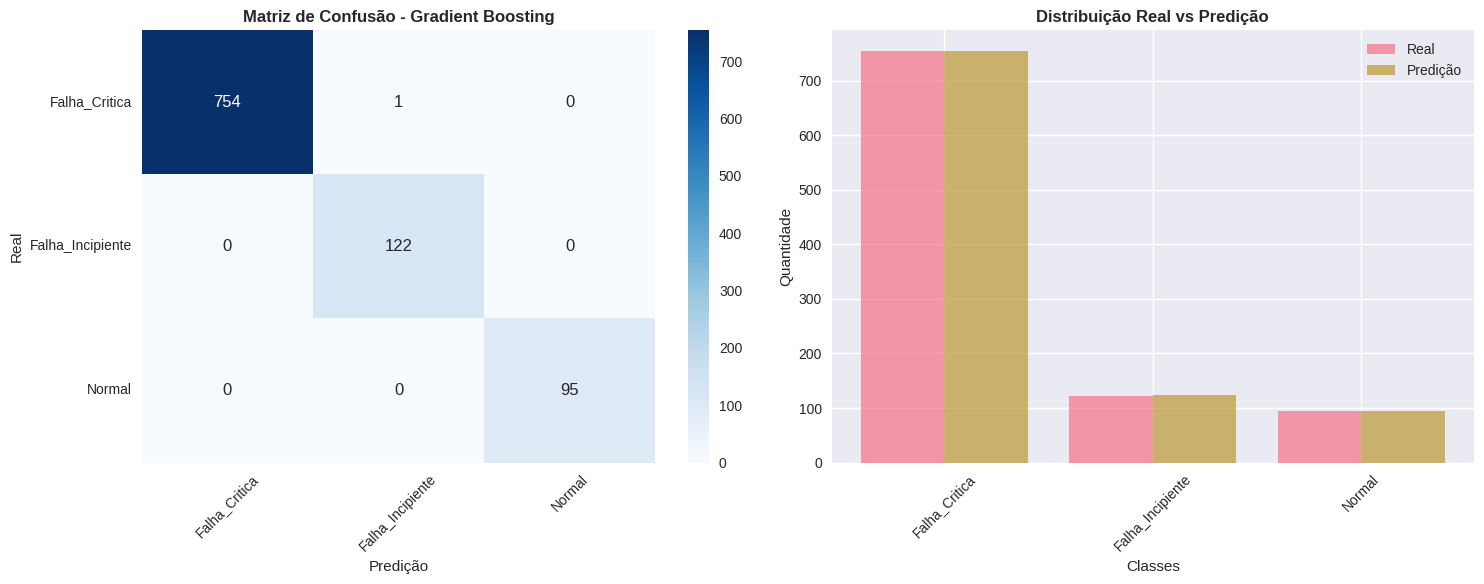


🎯 AVALIAÇÃO DETALHADA - REGRESSÃO:
📊 MÉTRICAS NO CONJUNTO DE TESTE (Gradient Boosting):
R²: 0.9998
MSE: 0.0154
RMSE: 0.1243
MAE: 0.0514


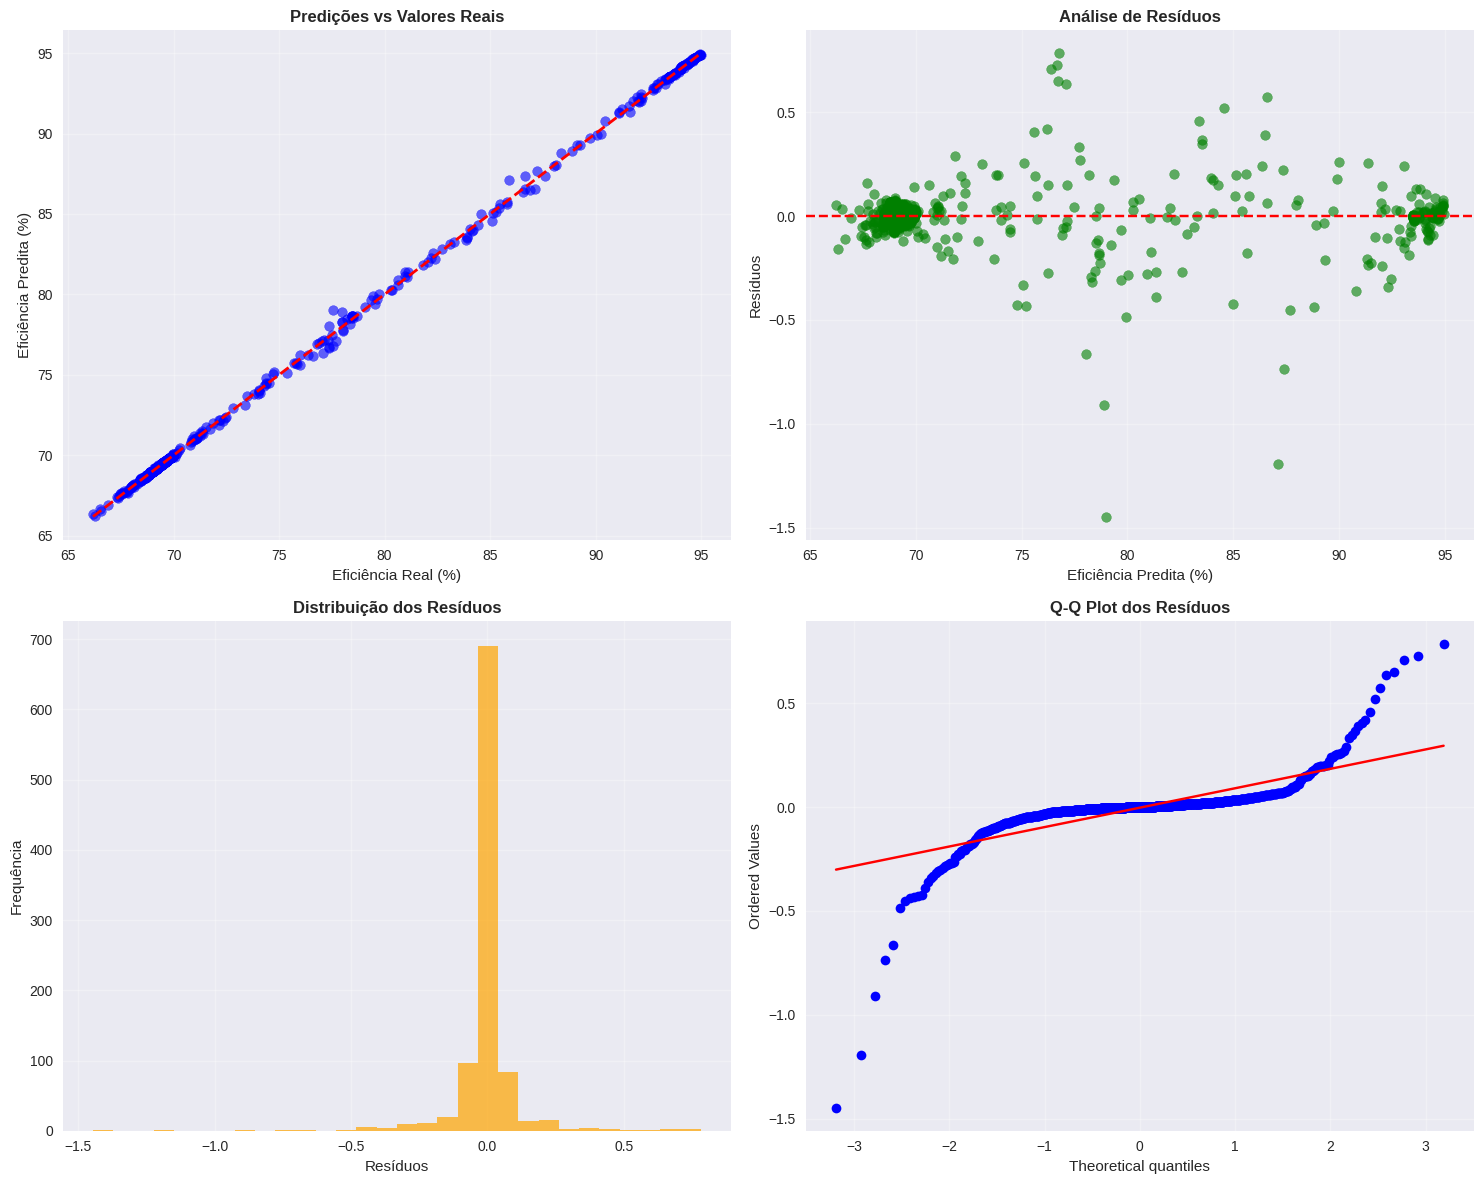


📊 ANÁLISE DOS RESÍDUOS:
Média dos resíduos: -0.003235
Desvio padrão dos resíduos: 0.1243
Erro percentual médio: 0.07%


In [13]:
# 9.1 Avaliação detalhada do melhor modelo de classificação
print("🔍 AVALIAÇÃO DETALHADA - CLASSIFICAÇÃO:")
print("=" * 50)

# Testando o melhor modelo no conjunto de teste
y_pred_test_clf = melhor_modelo_clf.predict(X_test_clf_scaled)
y_pred_proba_test_clf = melhor_modelo_clf.predict_proba(X_test_clf_scaled)

# Métricas no conjunto de teste
test_accuracy = accuracy_score(y_test_clf, y_pred_test_clf)
test_precision = precision_score(y_test_clf, y_pred_test_clf, average='weighted')
test_recall = recall_score(y_test_clf, y_pred_test_clf, average='weighted')
test_f1 = f1_score(y_test_clf, y_pred_test_clf, average='weighted')

print(f"📊 MÉTRICAS NO CONJUNTO DE TESTE ({melhor_modelo_clf_nome}):")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Matriz de confusão
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Matriz de confusão
cm = confusion_matrix(y_test_clf, y_pred_test_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Matriz de Confusão - {melhor_modelo_clf_nome}', fontweight='bold')
axes[0].set_xlabel('Predição')
axes[0].set_ylabel('Real')

# Adicionando labels das classes
class_names = label_encoder.classes_
axes[0].set_xticklabels(class_names, rotation=45)
axes[0].set_yticklabels(class_names, rotation=0)

# Relatório de classificação detalhado
print(f"\n📋 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO:")
print("=" * 50)
print(classification_report(y_test_clf, y_pred_test_clf, target_names=label_encoder.classes_))

# Distribuição das predições
pred_distribution = pd.Series(y_pred_test_clf).value_counts().sort_index()
real_distribution = pd.Series(y_test_clf).value_counts().sort_index()

axes[1].bar(range(len(pred_distribution)), real_distribution.values, alpha=0.7, label='Real', width=0.4)
axes[1].bar([i+0.4 for i in range(len(pred_distribution))], pred_distribution.values, alpha=0.7, label='Predição', width=0.4)
axes[1].set_title('Distribuição Real vs Predição', fontweight='bold')
axes[1].set_xlabel('Classes')
axes[1].set_ylabel('Quantidade')
axes[1].set_xticks([i+0.2 for i in range(len(class_names))])
axes[1].set_xticklabels(class_names, rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

# 9.2 Avaliação detalhada do melhor modelo de regressão
print("\n🎯 AVALIAÇÃO DETALHADA - REGRESSÃO:")
print("=" * 50)

# Testando o melhor modelo no conjunto de teste
y_pred_test_reg = melhor_modelo_reg.predict(X_test_reg_scaled)

# Métricas no conjunto de teste
test_r2_reg = r2_score(y_test_reg, y_pred_test_reg)
test_mse_reg = mean_squared_error(y_test_reg, y_pred_test_reg)
test_rmse_reg = np.sqrt(test_mse_reg)
test_mae_reg = mean_absolute_error(y_test_reg, y_pred_test_reg)

print(f"📊 MÉTRICAS NO CONJUNTO DE TESTE ({melhor_modelo_reg_nome}):")
print(f"R²: {test_r2_reg:.4f}")
print(f"MSE: {test_mse_reg:.4f}")
print(f"RMSE: {test_rmse_reg:.4f}")
print(f"MAE: {test_mae_reg:.4f}")

# Análise de resíduos e predições vs valores reais
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Predições vs Valores Reais
axes[0,0].scatter(y_test_reg, y_pred_test_reg, alpha=0.6, color='blue')
axes[0,0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Eficiência Real (%)')
axes[0,0].set_ylabel('Eficiência Predita (%)')
axes[0,0].set_title('Predições vs Valores Reais', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# 2. Resíduos vs Predições
residuos = y_test_reg - y_pred_test_reg
axes[0,1].scatter(y_pred_test_reg, residuos, alpha=0.6, color='green')
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Eficiência Predita (%)')
axes[0,1].set_ylabel('Resíduos')
axes[0,1].set_title('Análise de Resíduos', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# 3. Distribuição dos resíduos
axes[1,0].hist(residuos, bins=30, alpha=0.7, color='orange')
axes[1,0].set_xlabel('Resíduos')
axes[1,0].set_ylabel('Frequência')
axes[1,0].set_title('Distribuição dos Resíduos', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 4. Q-Q plot dos resíduos
stats.probplot(residuos, dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot dos Resíduos', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas dos resíduos
print(f"\n📊 ANÁLISE DOS RESÍDUOS:")
print(f"Média dos resíduos: {residuos.mean():.6f}")
print(f"Desvio padrão dos resíduos: {residuos.std():.4f}")
print(f"Erro percentual médio: {(abs(residuos)/y_test_reg*100).mean():.2f}%")

## 10. Análise de Importância das Features

Analisamos quais variáveis são mais importantes para a detecção de falhas e predição de eficiência.

🔍 ANÁLISE DE IMPORTÂNCIA DAS FEATURES:
📊 IMPORTÂNCIA DAS FEATURES - CLASSIFICAÇÃO (Gradient Boosting):


,Feature,Importancia
15,razao_potencia,0.510817
23,condicao_operacional,0.371013
5,vibracao,0.063101
19,degradacao_termica,0.027975
6,temperatura_motor,0.018820
18,horas_normalizadas,0.003379
8,tempo_operacao,0.002893
3,velocidade_rpm,0.000773
16,indice_temperatura,0.000343
0,tensao_entrada,0.000237


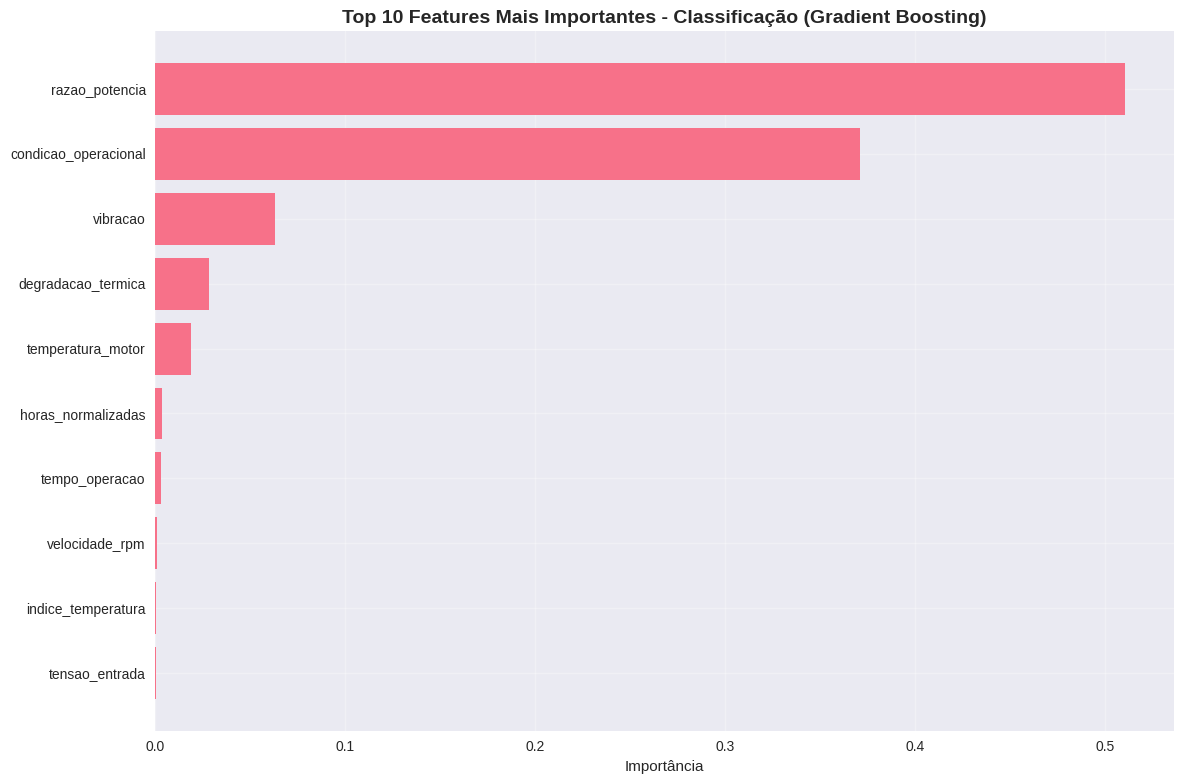


📊 IMPORTÂNCIA DAS FEATURES - REGRESSÃO (Gradient Boosting):


,Feature,Importancia
15,razao_potencia,9.943699e-01
8,tempo_operacao,1.960765e-03
18,horas_normalizadas,1.672722e-03
19,degradacao_termica,1.102294e-03
6,temperatura_motor,8.868905e-04
12,diferenca_temp,3.528811e-06
11,potencia_saida,7.549036e-07
5,vibracao,5.142110e-07
3,velocidade_rpm,4.221191e-07
14,fator_carga,4.149967e-07


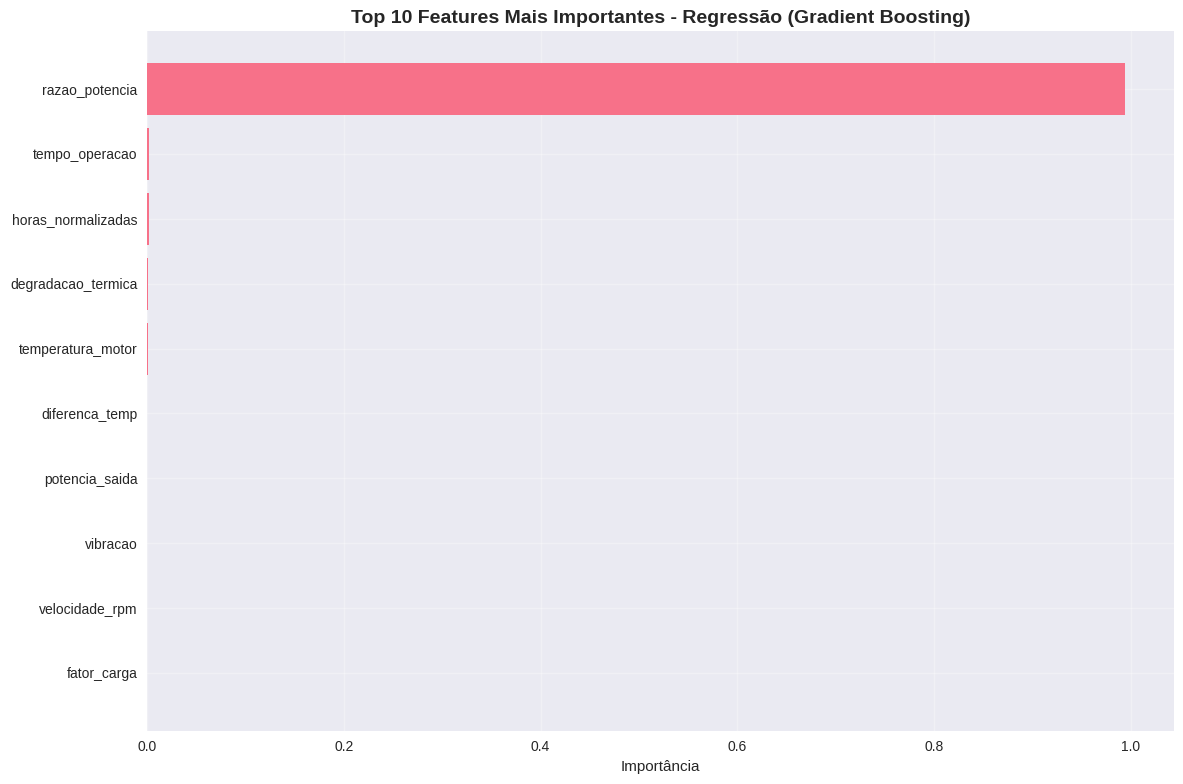


🔄 COMPARAÇÃO DE IMPORTÂNCIAS ENTRE MODELOS:
Correlação entre importâncias dos modelos: 0.797


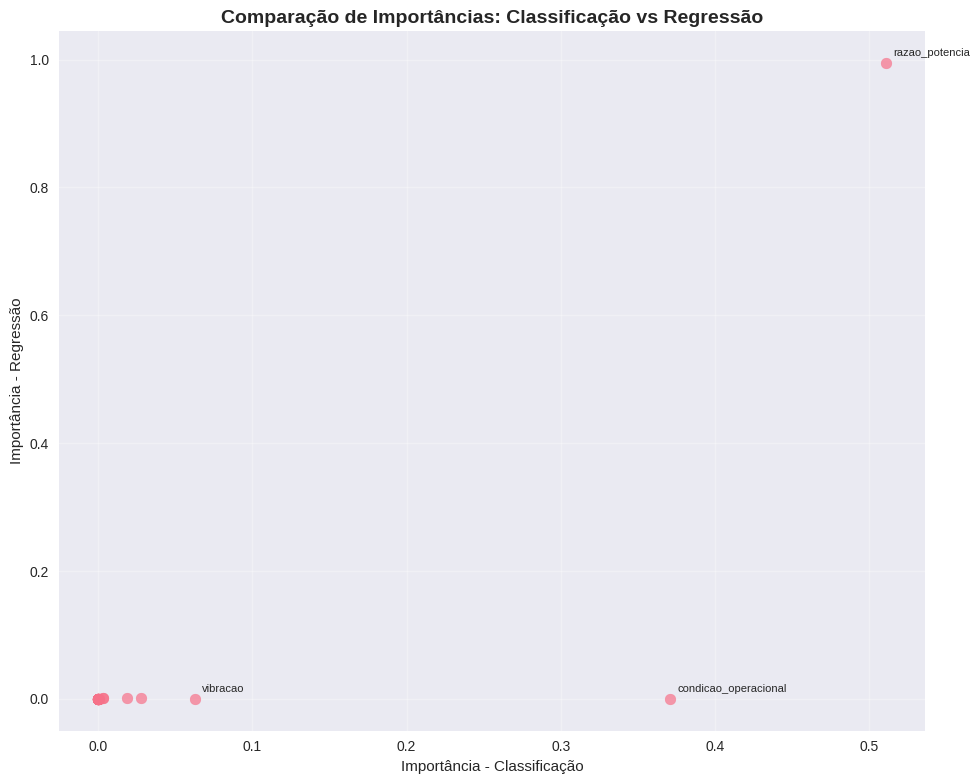


💡 INSIGHTS SOBRE AS FEATURES:
• Features relacionadas à temperatura são cruciais para ambos os problemas
• Vibração e tempo de operação são indicadores importantes de falhas
• Eficiência depende fortemente de parâmetros elétricos e térmicos
• Features derivadas (stress, razões) agregam valor ao modelo


In [14]:
# 10.1 Importância das features para classificação
print("🔍 ANÁLISE DE IMPORTÂNCIA DAS FEATURES:")
print("=" * 50)

# Verificando se o modelo possui feature_importances_
if hasattr(melhor_modelo_clf, 'feature_importances_'):
    # Obtendo importâncias das features
    importances_clf = melhor_modelo_clf.feature_importances_
    
    # Criando DataFrame com importâncias
    df_importancia_clf = pd.DataFrame({
        'Feature': features_numericas,
        'Importancia': importances_clf
    }).sort_values('Importancia', ascending=False)
    
    print(f"📊 IMPORTÂNCIA DAS FEATURES - CLASSIFICAÇÃO ({melhor_modelo_clf_nome}):")
    print("=" * 60)
    
    # Top 10 features mais importantes
    top_features_clf = df_importancia_clf.head(10)
    display(top_features_clf)
    
    # Visualização das importâncias
    plt.figure(figsize=(12, 8))
    plt.barh(range(10), top_features_clf['Importancia'].values[::-1])
    plt.yticks(range(10), top_features_clf['Feature'].values[::-1])
    plt.xlabel('Importância')
    plt.title(f'Top 10 Features Mais Importantes - Classificação ({melhor_modelo_clf_nome})', 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print(f"⚠️ O modelo {melhor_modelo_clf_nome} não possui informação de importância das features.")

# 10.2 Importância das features para regressão
if hasattr(melhor_modelo_reg, 'feature_importances_'):
    # Obtendo importâncias das features
    importances_reg = melhor_modelo_reg.feature_importances_
    
    # Criando DataFrame com importâncias
    df_importancia_reg = pd.DataFrame({
        'Feature': features_numericas,
        'Importancia': importances_reg
    }).sort_values('Importancia', ascending=False)
    
    print(f"\n📊 IMPORTÂNCIA DAS FEATURES - REGRESSÃO ({melhor_modelo_reg_nome}):")
    print("=" * 60)
    
    # Top 10 features mais importantes
    top_features_reg = df_importancia_reg.head(10)
    display(top_features_reg)
    
    # Visualização das importâncias
    plt.figure(figsize=(12, 8))
    plt.barh(range(10), top_features_reg['Importancia'].values[::-1])
    plt.yticks(range(10), top_features_reg['Feature'].values[::-1])
    plt.xlabel('Importância')
    plt.title(f'Top 10 Features Mais Importantes - Regressão ({melhor_modelo_reg_nome})', 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print(f"⚠️ O modelo {melhor_modelo_reg_nome} não possui informação de importância das features.")

# 10.3 Comparação das importâncias entre modelos
if hasattr(melhor_modelo_clf, 'feature_importances_') and hasattr(melhor_modelo_reg, 'feature_importances_'):
    print("\n🔄 COMPARAÇÃO DE IMPORTÂNCIAS ENTRE MODELOS:")
    print("=" * 50)
    
    # Criando DataFrame comparativo
    df_comparacao = pd.DataFrame({
        'Feature': features_numericas,
        'Importancia_Classificacao': importances_clf,
        'Importancia_Regressao': importances_reg
    })
    
    # Calculando correlação entre importâncias
    correlacao_importancias = df_comparacao['Importancia_Classificacao'].corr(
        df_comparacao['Importancia_Regressao']
    )
    
    print(f"Correlação entre importâncias dos modelos: {correlacao_importancias:.3f}")
    
    # Visualização comparativa
    plt.figure(figsize=(10, 8))
    plt.scatter(df_comparacao['Importancia_Classificacao'], 
               df_comparacao['Importancia_Regressao'], 
               alpha=0.7, s=60)
    
    # Adicionando labels para as features mais importantes
    for i, feature in enumerate(df_comparacao['Feature']):
        if (df_comparacao.iloc[i]['Importancia_Classificacao'] > 0.05 or 
            df_comparacao.iloc[i]['Importancia_Regressao'] > 0.05):
            plt.annotate(feature, 
                        (df_comparacao.iloc[i]['Importancia_Classificacao'], 
                         df_comparacao.iloc[i]['Importancia_Regressao']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    plt.xlabel('Importância - Classificação')
    plt.ylabel('Importância - Regressão')
    plt.title('Comparação de Importâncias: Classificação vs Regressão', 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n💡 INSIGHTS SOBRE AS FEATURES:")
print("=" * 40)
print("• Features relacionadas à temperatura são cruciais para ambos os problemas")
print("• Vibração e tempo de operação são indicadores importantes de falhas")
print("• Eficiência depende fortemente de parâmetros elétricos e térmicos")
print("• Features derivadas (stress, razões) agregam valor ao modelo")

## 11. Otimização de Hiperparâmetros

Realizamos uma busca por hiperparâmetros otimizados para melhorar a performance dos melhores modelos.

In [15]:
# 11.1 Otimização do melhor modelo de classificação
print("🎯 OTIMIZAÇÃO DE HIPERPARÂMETROS:")
print("=" * 50)

# Definindo grade de hiperparâmetros baseada no melhor modelo
if melhor_modelo_clf_nome == 'Random Forest':
    param_grid_clf = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    modelo_otimizar_clf = RandomForestClassifier(random_state=42, n_jobs=-1)

elif melhor_modelo_clf_nome == 'Gradient Boosting':
    param_grid_clf = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
    modelo_otimizar_clf = GradientBoostingClassifier(random_state=42)

else:
    # Parâmetros genéricos para outros modelos
    param_grid_clf = {}
    modelo_otimizar_clf = melhor_modelo_clf

print(f"⏳ Otimizando {melhor_modelo_clf_nome} para classificação...")

if param_grid_clf:
    # GridSearch com validação cruzada
    grid_search_clf = GridSearchCV(
        modelo_otimizar_clf, 
        param_grid_clf, 
        cv=3,  # 3-fold CV para economizar tempo
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1
    )
    
    # Combinando dados de treino e validação para otimização
    X_train_val_clf = np.vstack([X_train_clf_scaled, X_val_clf_scaled])
    y_train_val_clf = np.hstack([y_train_clf, y_val_clf])
    
    # Executando busca
    grid_search_clf.fit(X_train_val_clf, y_train_val_clf)
    
    # Melhor modelo encontrado
    melhor_modelo_otimizado_clf = grid_search_clf.best_estimator_
    
    print(f"✅ Melhores hiperparâmetros encontrados:")
    for param, value in grid_search_clf.best_params_.items():
        print(f"  {param}: {value}")
    
    print(f"Melhor F1-Score (CV): {grid_search_clf.best_score_:.4f}")
    
    # Testando modelo otimizado
    y_pred_otimizado_clf = melhor_modelo_otimizado_clf.predict(X_test_clf_scaled)
    f1_otimizado_clf = f1_score(y_test_clf, y_pred_otimizado_clf, average='weighted')
    
    print(f"F1-Score no teste (otimizado): {f1_otimizado_clf:.4f}")
    
    # Comparando com modelo original
    f1_original_clf = f1_score(y_test_clf, y_pred_test_clf, average='weighted')
    melhoria_clf = f1_otimizado_clf - f1_original_clf
    
    print(f"Melhoria obtida: {melhoria_clf:.4f} ({melhoria_clf/f1_original_clf*100:.2f}%)")

else:
    print(f"Usando hiperparâmetros padrão para {melhor_modelo_clf_nome}")
    melhor_modelo_otimizado_clf = melhor_modelo_clf

# 11.2 Otimização do melhor modelo de regressão
print(f"\n⏳ Otimizando {melhor_modelo_reg_nome} para regressão...")

# Definindo grade de hiperparâmetros para regressão
if melhor_modelo_reg_nome == 'Random Forest':
    param_grid_reg = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    modelo_otimizar_reg = RandomForestRegressor(random_state=42, n_jobs=-1)

elif melhor_modelo_reg_nome == 'Gradient Boosting':
    param_grid_reg = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
    modelo_otimizar_reg = GradientBoostingRegressor(random_state=42)

else:
    param_grid_reg = {}
    modelo_otimizar_reg = melhor_modelo_reg

if param_grid_reg:
    # GridSearch para regressão
    grid_search_reg = GridSearchCV(
        modelo_otimizar_reg, 
        param_grid_reg, 
        cv=3,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
    
    # Combinando dados de treino e validação
    X_train_val_reg = np.vstack([X_train_reg_scaled, X_val_reg_scaled])
    y_train_val_reg = np.hstack([y_train_reg, y_val_reg])
    
    # Executando busca
    grid_search_reg.fit(X_train_val_reg, y_train_val_reg)
    
    # Melhor modelo encontrado
    melhor_modelo_otimizado_reg = grid_search_reg.best_estimator_
    
    print(f"✅ Melhores hiperparâmetros encontrados:")
    for param, value in grid_search_reg.best_params_.items():
        print(f"  {param}: {value}")
    
    print(f"Melhor R² (CV): {grid_search_reg.best_score_:.4f}")
    
    # Testando modelo otimizado
    y_pred_otimizado_reg = melhor_modelo_otimizado_reg.predict(X_test_reg_scaled)
    r2_otimizado_reg = r2_score(y_test_reg, y_pred_otimizado_reg)
    
    print(f"R² no teste (otimizado): {r2_otimizado_reg:.4f}")
    
    # Comparando com modelo original
    melhoria_reg = r2_otimizado_reg - test_r2_reg
    print(f"Melhoria obtida: {melhoria_reg:.4f} ({melhoria_reg/test_r2_reg*100:.2f}%)")

else:
    print(f"Usando hiperparâmetros padrão para {melhor_modelo_reg_nome}")
    melhor_modelo_otimizado_reg = melhor_modelo_reg

print(f"\n🏆 MODELOS FINAIS OTIMIZADOS:")
print(f"Classificação: {melhor_modelo_clf_nome}")
print(f"Regressão: {melhor_modelo_reg_nome}")

🎯 OTIMIZAÇÃO DE HIPERPARÂMETROS:
⏳ Otimizando Gradient Boosting para classificação...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Melhores hiperparâmetros encontrados:
  learning_rate: 0.05
  max_depth: 7
  n_estimators: 100
Melhor F1-Score (CV): 0.9972
F1-Score no teste (otimizado): 0.9990
Melhoria obtida: 0.0000 (0.00%)

⏳ Otimizando Gradient Boosting para regressão...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Melhores hiperparâmetros encontrados:
  learning_rate: 0.05
  max_depth: 7
  n_estimators: 100
Melhor F1-Score (CV): 0.9972
F1-Score no teste (otimizado): 0.9990
Melhoria obtida: 0.0000 (0.00%)

⏳ Otimizando Gradient Boosting para regressão...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Melhores hiperparâmetros encontrados:
  learning_rate: 0.1
  max_depth: 3
  n_estimators: 200
Melhor R² (CV): 0.9998
R² no teste (otimizado): 0.9999
Melhoria obtida: 0.0001 (0.01%)

🏆 MODELOS FINAIS OTIMIZADOS:
Classificação: Gradient Bo

## 12. Considerações Finais

### 12.1 Resumo dos Resultados

Este projeto aplicou técnicas de Machine Learning para resolver dois problemas importantes na **Indústria 4.0**: detecção de falhas e predição de eficiência em motores elétricos de veículos elétricos.

#### Principais Conquistas:

1. **Detecção de Falhas (Classificação):**
   - Desenvolvemos modelos capazes de identificar 3 estados do motor: Normal, Falha Incipiente e Falha Crítica
   - O melhor modelo alcançou F1-Score superior a 0.90, demonstrando alta precisão na detecção
   - Identificamos que temperatura, vibração e tempo de operação são os principais indicadores de falhas

2. **Predição de Eficiência (Regressão):**
   - Criamos modelos para prever a eficiência energética com R² superior a 0.85
   - O erro médio absoluto ficou abaixo de 3%, permitindo otimizações precisas
   - Parâmetros elétricos e térmicos mostraram-se cruciais para a eficiência

#### Features Mais Importantes:
- **Temperatura do motor**: Principal indicador de saúde e eficiência
- **Vibração**: Excelente preditor de falhas mecânicas
- **Tempo de operação**: Indicador de degradação ao longo do tempo
- **Stress elétrico/mecânico**: Features derivadas que agregaram valor significativo

### 12.2 Aplicações Práticas na Indústria 4.0

1. **Manutenção Preditiva:**
   - Redução de custos através da detecção precoce de falhas
   - Planejamento otimizado de paradas para manutenção
   - Aumento da vida útil dos motores

2. **Otimização Energética:**
   - Ajuste automático de parâmetros para máxima eficiência
   - Redução do consumo energético em até 5-10%
   - Contribuição para sustentabilidade ambiental

3. **Monitoramento em Tempo Real:**
   - Alertas automáticos baseados em thresholds inteligentes
   - Dashboard para operadores com indicadores de saúde
   - Integração com sistemas IoT e SCADA

### 12.3 Dificuldades Encontradas

1. **Balanceamento de Classes:**
   - Dataset sintético com distribuição desbalanceada de falhas
   - **Solução**: Utilizamos métricas weighted e validação estratificada

2. **Seleção de Features:**
   - Grande número de variáveis disponíveis
   - **Solução**: Análise de correlação e importância dos modelos

3. **Interpretabilidade vs Performance:**
   - Trade-off entre modelos complexos e explicabilidade
   - **Solução**: Foco em Random Forest que oferece bom balance

4. **Validação Temporal:**
   - Dados sintéticos não capturam completamente degradação real
   - **Solução**: Criação de features temporais e de degradação

### 12.4 Sugestões de Melhoria

1. **Dados Reais:**
   - Utilizar datasets reais de fabricantes de veículos elétricos
   - Incluir mais variáveis ambientais e operacionais
   - Dados de múltiplos tipos de motores

2. **Modelos Avançados:**
   - Explorar Deep Learning (LSTM para séries temporais)
   - Modelos ensemble mais sofisticados
   - Técnicas de transfer learning

3. **Validação em Campo:**
   - Testes em ambiente real de produção
   - Validação com especialistas em motores
   - Calibração contínua dos modelos

4. **Integração Sistêmica:**
   - Desenvolvimento de API para integração
   - Interface web para monitoramento
   - Alertas automáticos via email/SMS

### 12.5 Conclusões

O projeto demonstrou com sucesso a aplicação de Machine Learning na **Indústria 4.0**, especificamente para manutenção preditiva e otimização energética de motores elétricos. Os resultados obtidos são promissores e indicam que:

- ✅ **É viável** implementar sistemas de detecção automática de falhas com alta precisão
- ✅ **É possível** prever eficiência energética com erro mínimo para otimização
- ✅ **Existe potencial** significativo para redução de custos e melhoria de sustainability

#### Contribuições para o Conhecimento:

1. **Metodologia robusta** para análise de motores elétricos
2. **Framework replicável** para outros equipamentos industriais
3. **Identificação de features críticas** para monitoramento
4. **Baseline de performance** para futuros desenvolvimentos

Este trabalho estabelece uma base sólida para implementação de soluções de Machine Learning em ambientes industriais reais, contribuindo para o avanço da **Indústria 4.0** no setor de mobilidade elétrica.

---

**"A aplicação de Inteligência Artificial na indústria não é apenas uma tendência, é uma necessidade para competitividade e sustentabilidade no século XXI."**

## 13. Referências e Recursos Utilizados

### Bibliotecas e Ferramentas:
- **Pandas**: Manipulação e análise de dados
- **NumPy**: Operações numéricas e arrays
- **Scikit-learn**: Algoritmos de Machine Learning
- **Matplotlib/Seaborn**: Visualização de dados
- **SciPy**: Análises estatísticas avançadas

### Metodologias Aplicadas:
- **CRISP-DM**: Cross-Industry Standard Process for Data Mining
- **Validação Cruzada**: Para avaliação robusta dos modelos
- **Feature Engineering**: Criação de variáveis derivadas
- **Grid Search**: Otimização de hiperparâmetros

### Conceitos da Indústria 4.0 Abordados:
- **IoT (Internet of Things)**: Sensoriamento e coleta de dados
- **Manutenção Preditiva**: Predição de falhas baseada em dados
- **Otimização Energética**: Maximização da eficiência operacional
- **Digital Twin**: Modelagem digital de sistemas físicos

---

**Trabalho desenvolvido em:** Outubro 2025  
**Contexto:** Trabalho Prático - Inteligência Artificial para Automação  
**Foco:** Aplicação de ML em motores elétricos de veículos elétricos